# **Telco Customer Churn Prediction**

**Problem Statement**

The telecom industry operates in a highly competitive environment where customer retention is critical, as acquiring new customers is significantly more expensive than retaining existing ones. Predicting customer churn is therefore essential for sustaining revenue and improving customer lifetime value.

This project analyzes data from a telecom company with `7,043` customers. The dataset includes customer demographics, service usage, billing details, and account information, along with whether a customer churned or remained with the company.

The objective is to develop a machine learning solution that can proactively identify customers at risk of churn before they leave. This involves predicting whether a customer will churn based on their profile and service usage, identifying the key factors driving churn, and providing actionable recommendations to improve customer retention.

The target variable is **Churn**, where `1` indicates a customer has left and `0` indicates they have stayed.

Since failing to identify a churner has a higher business cost than a false positive, **recall** is treated as the primary evaluation metric, supported by F1-score and AUC-ROC for overall model performance.

In [51]:
from google.colab import files
uploaded = files.upload()
print('Uploaded:', list(uploaded.keys()))

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv
Uploaded: ['WA_Fn-UseC_-Telco-Customer-Churn (1).csv']


# Importing Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

# Loading the Data

In [53]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nColumn names:')
print(df.columns.tolist())

Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

The dataset contains 7,043 customers and 21 columns. Each row represents a unique customer identified by customerID. The columns cover three broad areas — customer demographics (gender, SeniorCitizen, Partner, Dependents), services subscribed (PhoneService, InternetService, StreamingTV, etc.), and account information (Contract, PaymentMethod, MonthlyCharges, TotalCharges).

Upon initial inspection, several observations warrant attention. TotalCharges appears numeric but is stored as object type — customer 0 has identical values for both MonthlyCharges and TotalCharges at 29.85, suggesting a brand new customer with just 1 month of tenure whose total charges have not yet accumulated. SeniorCitizen is already encoded as 0/1, unlike the other Yes/No categorical columns. customerID is a unique identifier that carries no predictive value and will be dropped before modeling.

The target variable is Churn, a Yes/No flag indicating whether the customer left the company. This is what the predictive models will be trained to classify.

#  Data Overview

In [54]:
print('Data Types:')
print(df.dtypes)

print('\nMissing Values:')
print(df.isnull().sum().sort_values(ascending=False))

print('\nNumerical Summary:')
print(df.describe())

print('\nCategorical Summary:')
print(df.describe(include='object'))

print('\nChurn unique values (RAW):')
print(df['Churn'].unique())

print('\nMonthlyCharges unique sample:')
print(df['MonthlyCharges'].unique()[:10])

print('\nPaymentMethod unique values:')
print(df['PaymentMethod'].unique())

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 


An initial inspection of the dataset reveals 7,043 customer records across 21 attributes. While pandas reports zero missing values across all columns, this finding warrants closer examination. `TotalCharges`, which should be a continuous numeric variable, is stored as object type. The categorical summary reveals 11 records sharing an identical value for `TotalCharges`, strongly suggesting the presence of whitespace characters that pandas does not register as null. These records likely correspond to customers with zero tenure, where total charges have not yet been accrued. Explicit conversion to numeric type will be necessary to surface these as NaN for appropriate imputation.

With respect to data types, `MonthlyCharges` is correctly represented as float64. `SeniorCitizen` is already binary-encoded (0/1), requiring no further transformation. The target variable `Churn` contains exactly two values, "Yes" and "No", with no inconsistencies in casing or formatting.

The numerical summary indicates that customer tenure spans 0 to 72 months, with a median of 29 months and a mean of 32.37 months, suggesting a slight right skew. Monthly charges range from \$18.25 to \$118.75, with a mean of \$64.76. Approximately 16.2% of the customer base are senior citizens.

Preliminary examination of categorical features reveals that Fiber optic is the most prevalent internet service (3,096 customers), month-to-month contracts are the dominant contract type (3,875 customers), and electronic check is the most frequently used payment method (2,365 customers). The majority of customers do not subscribe to supplementary services such as online security, online backup, or tech support. These distributional patterns will be examined further in the exploratory analysis to assess their relationship with customer churn.

# Data Cleaning

In [55]:
# Drop identifier column - carries no predictive value
df.drop('customerID', axis=1, inplace=True)

# Encode target variable
df['Churn'] = df['Churn'].str.strip().str.lower().map({'yes': 1, 'no': 0})

# Normalize all remaining string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

# Convert TotalCharges to numeric - blank spaces surface as NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Impute missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print('Nulls after cleaning:')
print(df.isnull().sum().sort_values(ascending=False))

print('\nChurn value counts:')
print(df['Churn'].value_counts())

print('\nPaymentMethod unique values after cleaning:')
print(df['PaymentMethod'].unique())

print('\nTenure min:', df['tenure'].min())
print('TotalCharges dtype:', df['TotalCharges'].dtype)

Nulls after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

PaymentMethod unique values after cleaning:
['electronic check' 'mailed check' 'bank transfer (automatic)'
 'credit card (automatic)']

Tenure min: 0
TotalCharges dtype: float64


Following the data cleaning procedure, the dataset is now fully prepared for analysis. All 20 features (after dropping customerID) register zero null values. The 11 blank entries in TotalCharges that were masked as whitespace have been successfully surfaced through numeric coercion and imputed with the column median, a conservative approach that avoids distorting the distribution.

The target variable Churn has been encoded as a binary integer, with 5,174 customers labeled as non-churners (0) and 1,869 as churners (1). This translates to a churn rate of approximately 26.5%, indicating a moderate class imbalance of roughly 2.8:1. This imbalance is not severe enough to render standard metrics meaningless, but it is significant enough to warrant a resampling strategy during model training to prevent the classifier from being biased toward the majority class.

PaymentMethod has normalized cleanly into four distinct categories with no duplicates or casing inconsistencies. Tenure minimum is confirmed at 0, corresponding to brand new customers. TotalCharges is now correctly stored as float64.
The dataset is clean, consistent, and ready for exploratory data analysis.

# Exploratory Data Analysis

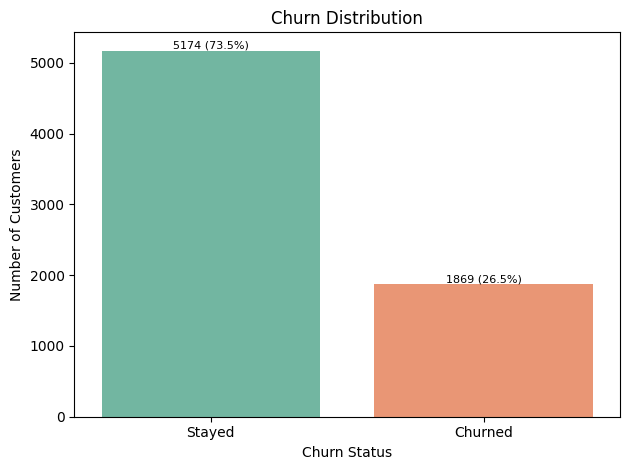

In [56]:
# Churn Distribution
total = len(df)
ax = sns.countplot(x='Churn', data=df, hue='Churn', palette='Set2', legend=False)
plt.title('Churn Distribution')
plt.xticks(ticks=[0, 1], labels=['Stayed', 'Churned'])
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f'{count} ({pct:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

The distribution of the target variable reveals that 26.5% of customers, approximately 1,869 out of 7,043, have churned. The remaining 73.5%, around 5,174 customers, have stayed with the company. This confirms a class imbalance of roughly 2.8:1 in favor of the non-churn class.

While this imbalance is not extreme, it is sufficient to bias a classifier toward predicting the majority class if left unaddressed. A model that simply predicts "No Churn" for every customer would achieve 73.5% accuracy while completely failing to identify a single churner. This reinforces the need to prioritize recall over accuracy as the primary evaluation metric, and the class imbalance will be addressed appropriately during the model training phase

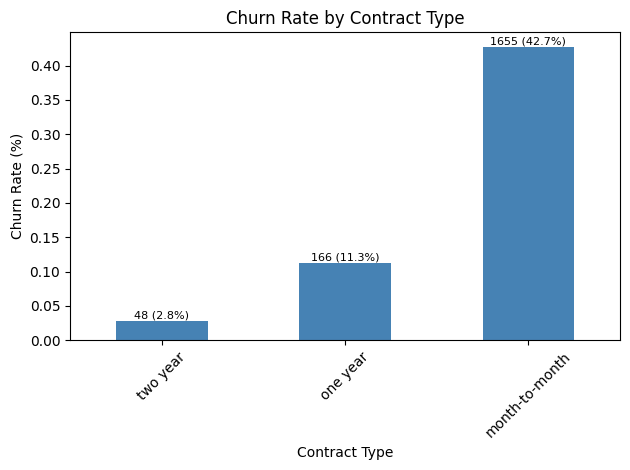

In [57]:
# Churn Rate by Contract Type
ax = df.groupby('Contract')['Churn'].mean().sort_values().plot(
    kind='bar', color='steelblue', title='Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract Type')
plt.xticks(rotation=45)

# Add count and percentage labels
contract_counts = df.groupby('Contract')['Churn']
for i, (name, val) in enumerate(df.groupby('Contract')['Churn'].mean().sort_values().items()):
    count = int(df[df['Contract'] == name]['Churn'].sum())
    total = len(df[df['Contract'] == name])
    ax.annotate(f'{count} ({val*100:.1f}%)',
                (i, val),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

An examination of churn rates across contract types reveals a striking pattern. Customers on month-to-month contracts exhibit a churn rate of 42.7%, accounting for 1,655 of the total 1,869 churners in the dataset. This is in sharp contrast to customers on one-year contracts, who churn at just 11.3%, and those on two-year contracts, who churn at a mere 2.8%.

This finding suggests that contract duration is one of the strongest indicators of customer retention. The absence of a long-term commitment appears to significantly lower the barrier for customers to leave, while longer contracts likely reflect a higher level of satisfaction or perceived switching cost. This variable is expected to be among the most important features in the predictive models.

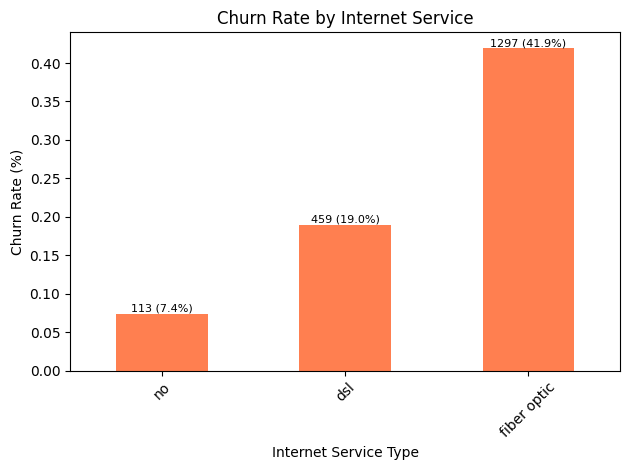

In [58]:
# Churn Rate by Internet Service
ax = df.groupby('InternetService')['Churn'].mean().sort_values().plot(
    kind='bar', color='coral', title='Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Internet Service Type')
plt.xticks(rotation=45)

for i, (name, val) in enumerate(df.groupby('InternetService')['Churn'].mean().sort_values().items()):
    count = int(df[df['InternetService'] == name]['Churn'].sum())
    ax.annotate(f'{count} ({val*100:.1f}%)',
                (i, val),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

The relationship between internet service type and churn reveals another important pattern. Customers subscribed to fiber optic service exhibit the highest churn rate at 41.9%, contributing 1,297 churners. DSL customers churn at a considerably lower rate of 19.0%, while customers with no internet service show the lowest churn rate of just 7.4%.

This is a notable finding. Fiber optic is typically the premium, higher-priced service tier, yet it carries the highest churn rate. This could indicate unmet expectations around service quality or price-to-value perception among fiber optic subscribers. This variable will likely interact strongly with monthly charges and contract type in the predictive models.

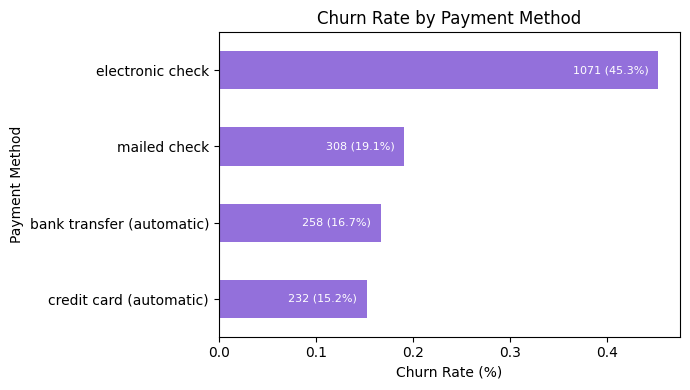

In [59]:
# Churn Rate by Payment Method
fig, ax = plt.subplots(figsize=(7, 4))
df.groupby('PaymentMethod')['Churn'].mean().sort_values().plot(
    kind='barh', color='mediumpurple', ax=ax)
ax.set_title('Churn Rate by Payment Method')
ax.set_xlabel('Churn Rate (%)')
ax.set_ylabel('Payment Method')

for i, (name, val) in enumerate(df.groupby('PaymentMethod')['Churn'].mean().sort_values().items()):
    count = int(df[df['PaymentMethod'] == name]['Churn'].sum())
    ax.annotate(f'{count} ({val*100:.1f}%)',
            (val - 0.01, i),
            ha='right', va='center', fontsize=8, color='white')
plt.tight_layout()
plt.show()

Payment method shows a clear divide between manual and automatic payment users. Electronic check customers churn at the highest rate of 45.3%, accounting for 1,071 churners. Mailed check follows at 19.1%, while both automatic payment methods, bank transfer and credit card, show notably lower churn rates of 16.7% and 15.2% respectively.

Customers on automatic payments appear significantly more likely to stay, possibly reflecting a higher degree of passive commitment or satisfaction. Electronic check users, by contrast, are actively involved in each payment cycle, which may correlate with higher price sensitivity or lower engagement with the service.

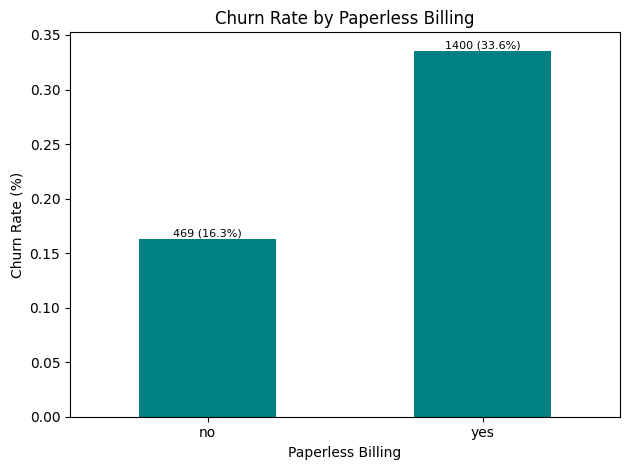

In [60]:
# Churn Rate by Paperless Billing
ax = df.groupby('PaperlessBilling')['Churn'].mean().sort_values().plot(
    kind='bar', color='teal', title='Churn Rate by Paperless Billing')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Paperless Billing')
plt.xticks(rotation=0)

for i, (name, val) in enumerate(df.groupby('PaperlessBilling')['Churn'].mean().sort_values().items()):
    count = int(df[df['PaperlessBilling'] == name]['Churn'].sum())
    ax.annotate(f'{count} ({val*100:.1f}%)',
                (i, val),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Customers enrolled in paperless billing churn at 33.6%, accounting for 1,400 churners, compared to just 16.3% among those receiving paper bills. While paperless billing itself is unlikely to cause churn directly, it likely acts as a proxy for a broader customer profile. Customers who opt for paperless billing tend to also use electronic check payments and month-to-month contracts, forming a high-risk behavioral cluster.


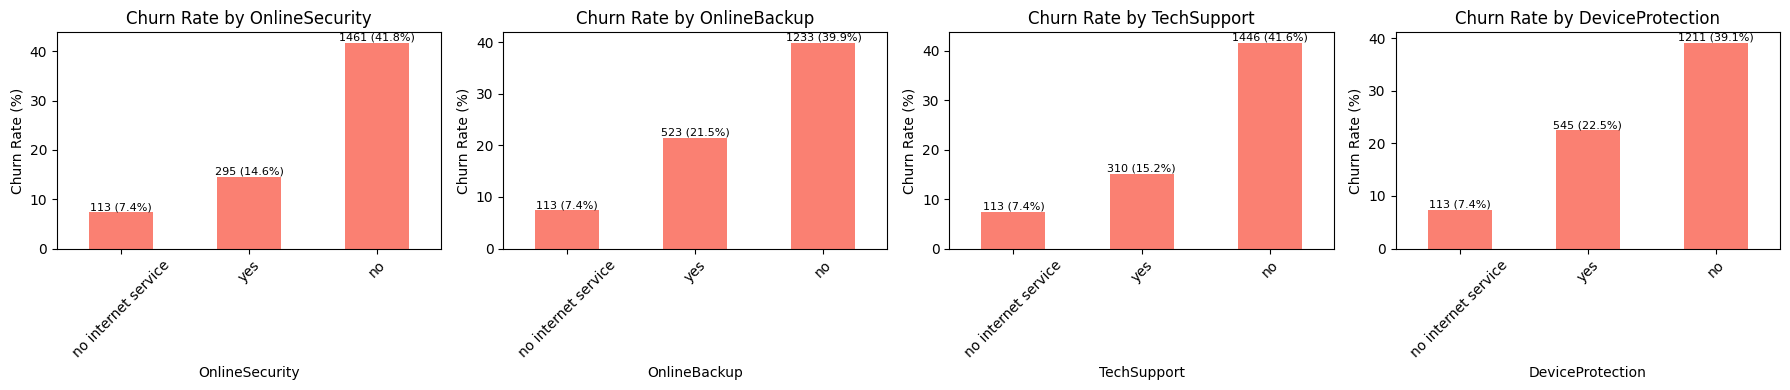

In [61]:
# Churn Rate by Supplementary Services
services = ['OnlineSecurity', 'OnlineBackup', 'TechSupport', 'DeviceProtection']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, services):
    rates = df.groupby(col)['Churn'].mean() * 100
    counts = df.groupby(col)['Churn'].sum()
    bars = rates.sort_values().plot(kind='bar', ax=ax, color='salmon')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)
    for i, (name, val) in enumerate(rates.sort_values().items()):
        count = int(counts[name])
        ax.annotate(f'{count} ({val:.1f}%)',
                    (i, val),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Across all four supplementary services, a consistent and striking pattern emerges. Customers without online security, online backup, tech support, or device protection churn at rates between 39% and 42%, while customers subscribed to these services churn at just 14% to 22%. Customers with no internet service at all show the lowest churn rate of 7.4% across all four categories.

This suggests that supplementary service adoption is a strong indicator of customer engagement and perceived value. Customers who invest in additional services are likely more embedded in the ecosystem and therefore less inclined to leave. Conversely, customers using only basic services with no add-ons represent a significantly higher churn risk.

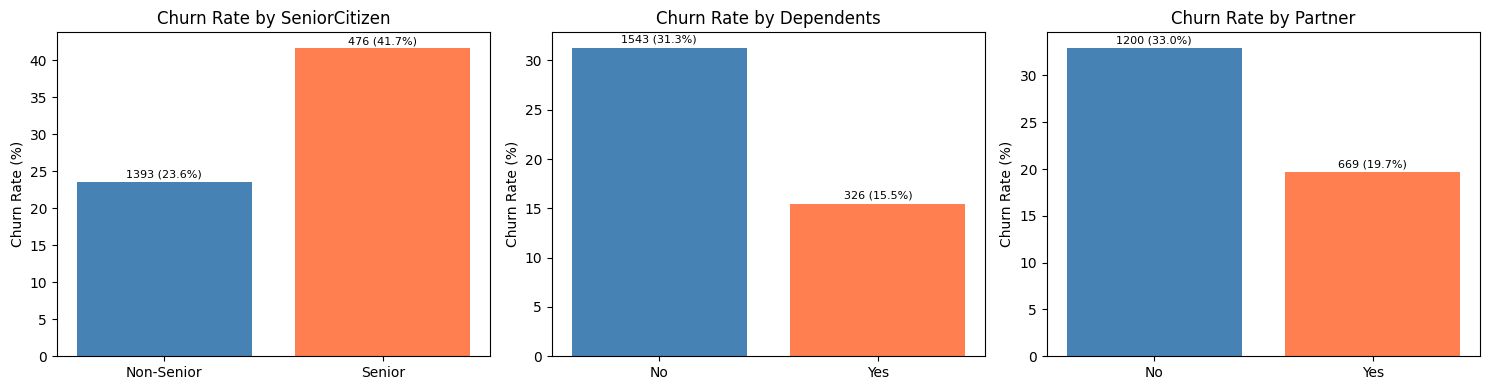

In [62]:
# Churn Rate by Senior Citizen, Dependents, Partner
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, labels in zip(axes,
    ['SeniorCitizen', 'Dependents', 'Partner'],
    [['Non-Senior', 'Senior'], ['No', 'Yes'], ['No', 'Yes']]):
    rates = df.groupby(col)['Churn'].mean() * 100
    counts = df.groupby(col)['Churn'].sum().values
    ax.bar(labels, rates.values, color=['steelblue', 'coral'])
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    for i, (v, c) in enumerate(zip(rates.values, counts)):
        ax.text(i, v + 0.5, f'{int(c)} ({v:.1f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Three demographic variables reveal consistent patterns in churn behavior. Senior citizens churn at 41.7% compared to 23.6% among non-seniors, suggesting that older customers may face greater difficulties with service complexity or price sensitivity.

Customers without dependents churn at 31.3%, nearly double the rate of those with dependents at 15.5%, indicating that family responsibilities may anchor customers to their current service provider. Similarly, customers without a partner churn at 33.0% compared to 19.7% among those with a partner.

Collectively, these findings suggest that customers with stronger domestic ties, whether through a partner or dependents, tend to exhibit greater loyalty. Single, independent customers with no family obligations represent a higher-risk demographic from a retention standpoint

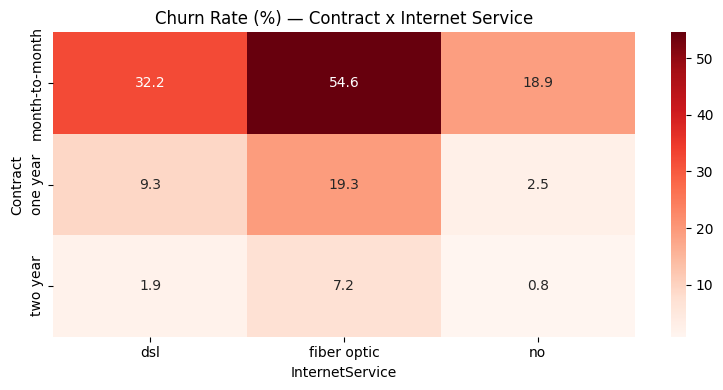

In [63]:
# Contract x Internet Service Heatmap
cross = df.groupby(['Contract', 'InternetService'])['Churn'].mean() * 100
plt.figure(figsize=(8, 4))
sns.heatmap(cross.unstack(), annot=True, fmt='.1f', cmap='Reds')
plt.title('Churn Rate (%) — Contract x Internet Service')
plt.tight_layout()
plt.show()

The interaction between contract type and internet service uncovers the highest risk segment in the dataset. Month-to-month fiber optic customers churn at an alarming rate of 54.6%, making them the single most vulnerable group. Month-to-month DSL customers follow at 32.2%, while those with no internet service on the same contract type churn at 18.9%.

Across all internet service types, moving from month-to-month to a two-year contract dramatically reduces churn. Fiber optic customers on two-year contracts churn at just 7.2%, compared to 54.6% on month-to-month. This reinforces the earlier finding that contract type is the dominant retention lever, and suggests that targeted efforts to migrate high-risk fiber optic customers onto longer contracts could yield significant reductions in overall churn.

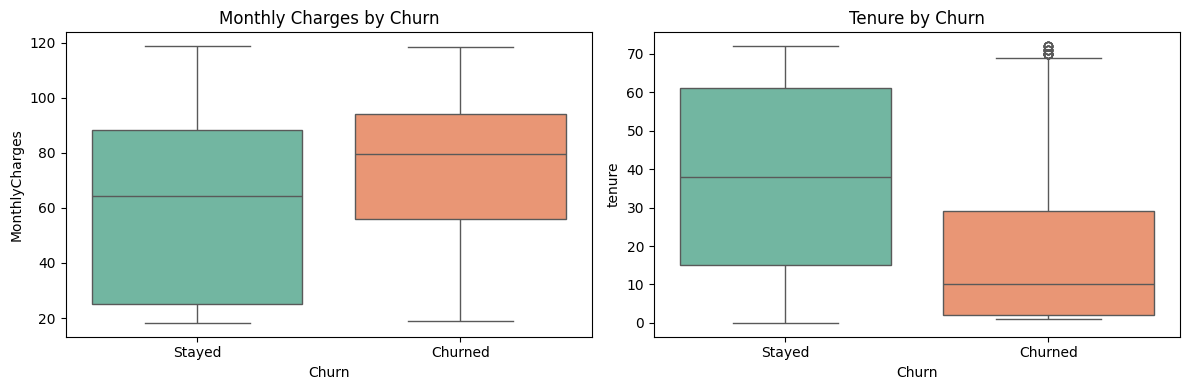

In [64]:
# Monthly Charges and Tenure by Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            hue='Churn', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Monthly Charges by Churn')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Stayed', 'Churned'])

sns.boxplot(x='Churn', y='tenure', data=df,
            hue='Churn', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Tenure by Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.show()

Churned customers tend to have higher monthly charges, with a median of approximately \$79 compared to \$64 for customers who stayed. This aligns with the earlier finding that fiber optic subscribers, who typically pay more, churn at higher rates. On the tenure side, the contrast is even more pronounced. Customers who stayed have a median tenure of around 38 months, while churned customers show a median of just 10 months, with the interquartile range heavily concentrated in the 0 to 29 month window. This strongly suggests that the early months of a customer's lifecycle represent the highest risk period.


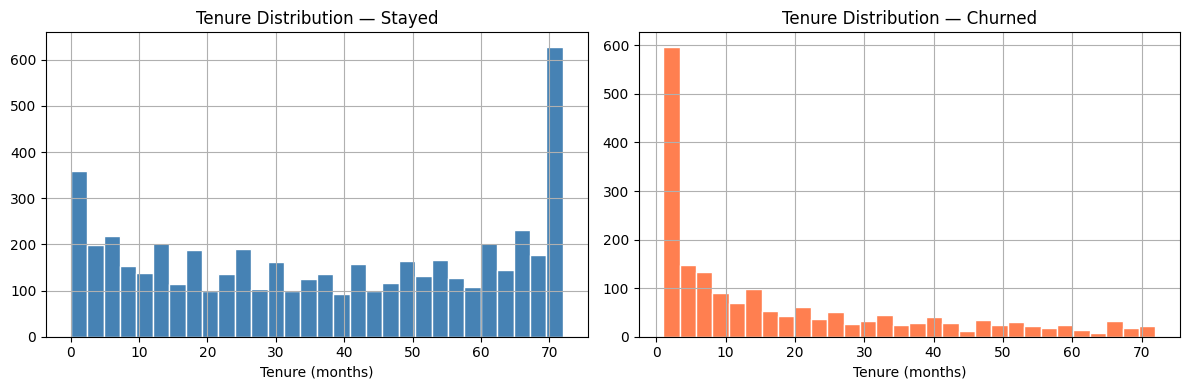

In [65]:
# Tenure Distribution Histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df['Churn']==0]['tenure'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Tenure Distribution — Stayed')
axes[0].set_xlabel('Tenure (months)')

df[df['Churn']==1]['tenure'].hist(bins=30, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Tenure Distribution — Churned')
axes[1].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.show()

The tenure histograms make the early-lifecycle churn pattern unmistakably clear. Among churned customers, the distribution is heavily right-skewed, with the largest spike occurring in the very first month and counts dropping sharply beyond month 10. Customers who stayed, by contrast, show a relatively uniform distribution across all tenure bands, with a notable peak at month 72, indicating a loyal long-term segment. The first 12 months emerge as the most critical retention window.

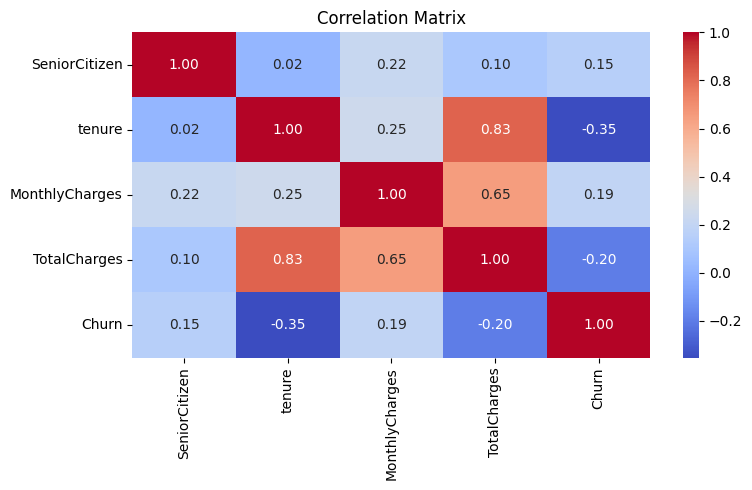

In [66]:
# Correlation Matrix
plt.figure(figsize=(8, 5))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

The correlation matrix reveals several important relationships. Tenure and TotalCharges are strongly correlated at 0.83, which is expected since total charges accumulate over time. MonthlyCharges and TotalCharges show a moderate correlation of 0.65. These two pairs of variables carry overlapping information and their individual feature importances in tree-based models should be interpreted with this in mind.

With respect to the target variable, tenure shows the strongest negative correlation with churn at -0.35, confirming that longer-tenured customers are less likely to leave. MonthlyCharges shows a modest positive correlation of 0.19, consistent with the boxplot findings. TotalCharges shows a slight negative correlation of -0.20, driven largely by its dependence on tenure rather than being an independent signal.

# Feature Preparation

In [67]:
# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# One-hot encode categorical columns
# drop_first=True avoids the dummy variable trap
X = pd.get_dummies(X, drop_first=True)

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature names:')
print(X.columns.tolist())

Features shape: (7043, 30)
Target shape: (7043,)

Feature names:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_male', 'Partner_yes', 'Dependents_yes', 'PhoneService_yes', 'MultipleLines_no phone service', 'MultipleLines_yes', 'InternetService_fiber optic', 'InternetService_no', 'OnlineSecurity_no internet service', 'OnlineSecurity_yes', 'OnlineBackup_no internet service', 'OnlineBackup_yes', 'DeviceProtection_no internet service', 'DeviceProtection_yes', 'TechSupport_no internet service', 'TechSupport_yes', 'StreamingTV_no internet service', 'StreamingTV_yes', 'StreamingMovies_no internet service', 'StreamingMovies_yes', 'Contract_one year', 'Contract_two year', 'PaperlessBilling_yes', 'PaymentMethod_credit card (automatic)', 'PaymentMethod_electronic check', 'PaymentMethod_mailed check']


The dataset contains 16 categorical variables which have been converted to numeric form using one-hot encoding. The `drop_first=True` parameter is applied to avoid multicollinearity introduced by the dummy variable trap, where one category per variable is used as the reference. This expands the feature space from 19 input variables to 30 binary and continuous features. The resulting feature set captures all meaningful categorical distinctions while remaining computationally efficient.



In [68]:
# Train-test split (stratified to preserve churn ratio)
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)
print('\nChurn ratio in train:', y_train.mean().round(3))
print('Churn ratio in test: ', y_test.mean().round(3))

Train size: (5634, 30)
Test size:  (1409, 30)

Churn ratio in train: 0.265
Churn ratio in test:  0.265


The dataset is divided into a training set of 5,634 records and a test set of 1,409 records, reflecting an 80-20 split. Stratified splitting is applied to ensure that the churn ratio of 26.5% is preserved in both subsets, confirmed by the identical churn ratios of 0.265 in both train and test sets. The test set will remain completely untouched during all training, cross-validation, and hyperparameter tuning steps, serving solely as the final evaluation holdout.

In [69]:
# Section 7: Model Building on Original Data (No SMOTE, No Scaling)
# We first evaluate all models on the raw imbalanced data to establish
# a true baseline and observe how each model behaves without any corrections.

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

models_original = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':        DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'KNN':                  KNeighborsClassifier(n_neighbors=5),
}

results_original = {}

for name, model in models_original.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results_original[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred) * 100, 2),
    }
    print(f'\n{"="*50}')
    print(f'  {name}')
    print('='*50)
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn', 'Churn']))

original_df = pd.DataFrame(results_original).T
print('\nSUMMARY — Original Data (sorted by Recall):')
print(original_df.sort_values('Recall', ascending=False))


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.82      0.83      0.83      1035
       Churn       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg     

The detailed classification reports reveal a clear asymmetry in model performance across the two classes. For the non-churn class, precision ranges from 81% to 85% and recall from 83% to 90%, meaning the models are relatively good at identifying customers who will stay. This is expected — with 73.5% of the training data belonging to the non-churn class, the models have far more examples of staying customers to learn from.

For the churn class however, the picture deteriorates significantly. Precision drops to between 51% and 65%, and recall falls to between 43% and 56%. In practical terms, precision of 51% for the Decision Tree means that out of every two customers it flags as churners, only one actually churns. A recall of 43% for KNN means the model is silently missing 57 out of every 100 actual churners — customers who would leave without any retention intervention being triggered.

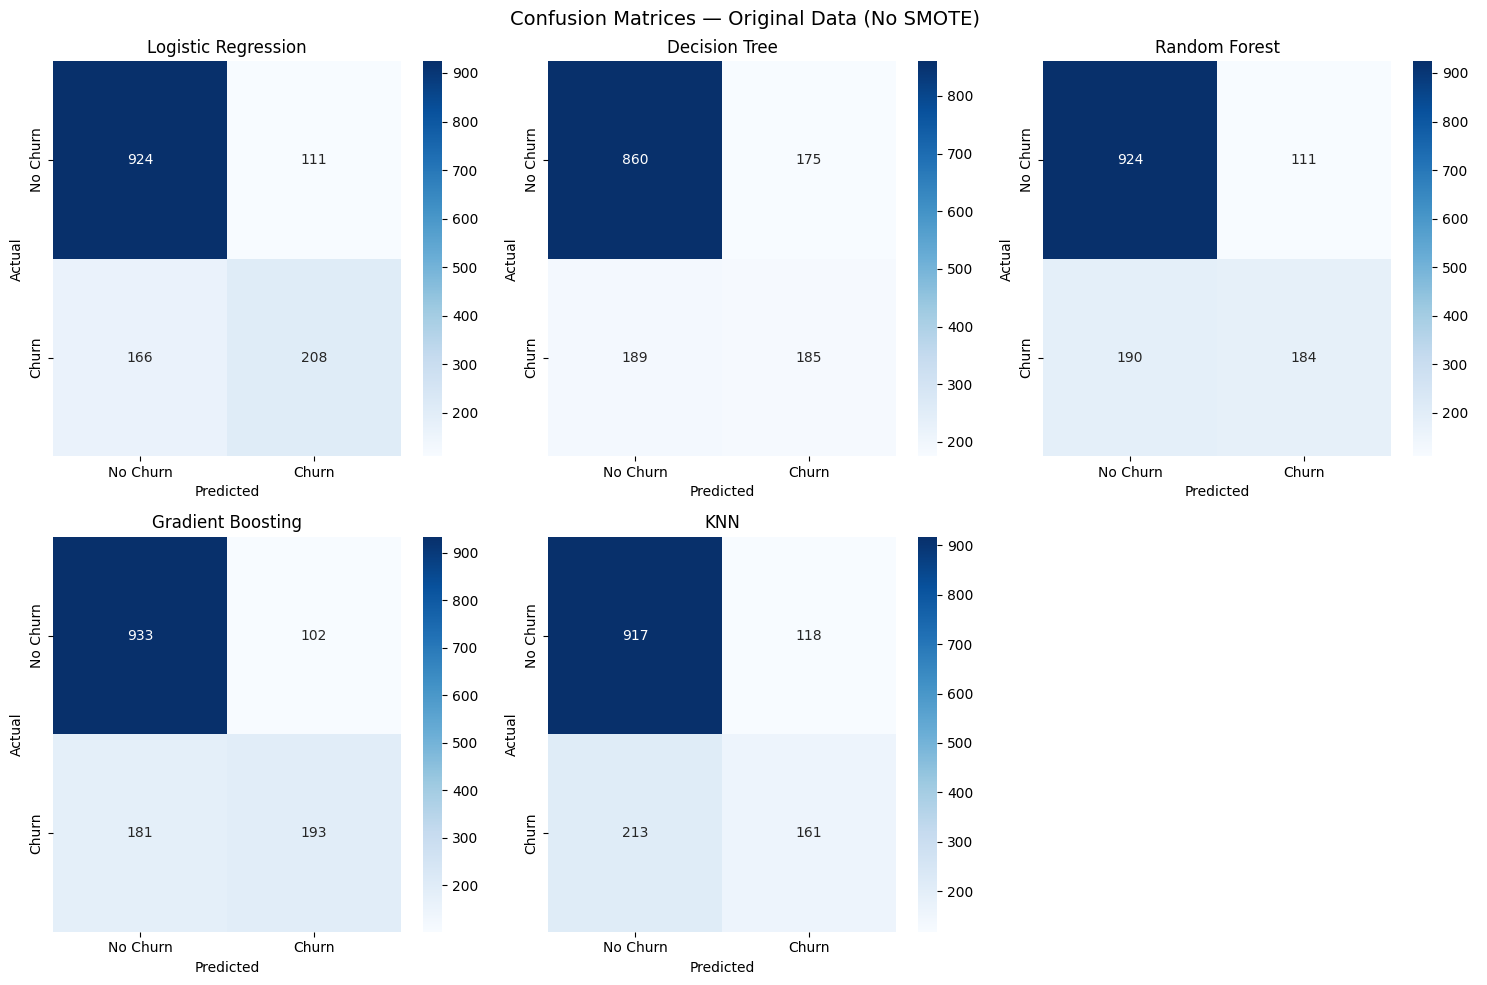

In [70]:
# Confusion matrices — Original Data
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models_original.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

axes[5].axis('off')
plt.suptitle('Confusion Matrices — Original Data (No SMOTE)', fontsize=14)
plt.tight_layout()
plt.show()

The confusion matrices provide a granular view of where each model fails. The bottom-left quadrant of each matrix represents false negatives, actual churners that the model predicted would stay. These are the most costly errors in a churn prediction context, as these are customers who would leave without any retention intervention being triggered.

KNN produces the highest false negative count at 213, meaning it silently misses 213 out of 374 actual churners. The Decision Tree misses 189, Random Forest misses 190, Logistic Regression misses 166, and Gradient Boosting misses 181 despite leading on overall accuracy.

Looking at the top-right quadrant, false positives represent customers who were flagged as churners but actually stayed. These counts are comparatively lower across all models, ranging from 102 for Gradient Boosting to 175 for the Decision Tree. This confirms that all five models are biased toward predicting the majority class. They are conservative about flagging churners, which keeps false alarms low but at the cost of missing a large proportion of actual churners.

In a business context where each missed churner represents lost revenue and a costly reacquisition effort, this tradeoff is unacceptable. The models need to become more sensitive to the churn class. The Decision Tree in particular shows both high false negatives at 189 and high false positives at 175, reflecting an unstable pattern that suggests the tree has grown too complex for the data it has seen. In the next section, we investigate whether controlling this complexity through pruning can improve the Decision Tree's ability to generalize.


# Decision Tree — Cost Complexity Pruning


The baseline evaluation revealed that the plain Decision Tree performed the weakest among all five models, with a recall of 49.5%, precision of 51.4%, and the highest combined false negative and false positive counts in the confusion matrix. This pattern is characteristic of an overfit model. An unpruned Decision Tree grows until it perfectly classifies every training example, creating hundreds of highly specific branches that capture noise rather than signal. When exposed to unseen test data, these overly specific branches fail to generalize, resulting in poor recall and unstable predictions.

Cost-Complexity Pruning addresses this by introducing a penalty parameter called ccp_alpha. As ccp_alpha increases, branches that contribute little to reducing impurity relative to their complexity cost are progressively removed. A higher alpha produces a simpler, more generalized tree. A lower alpha closer to zero produces a more complex tree that behaves similarly to the unpruned version. The goal is to find the alpha value that produces the best test recall, since that is our primary metric.

In [71]:
# Step 1: Compute the pruning path
# cost_complexity_pruning_path returns all alpha values at which
# the tree structure changes, along with the total impurity at each step.
# This gives us the full range of alpha candidates to evaluate.

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
path = dt_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(f'Total alpha candidates: {len(ccp_alphas)}')
print(f'Alpha range: {ccp_alphas.min():.6f} to {ccp_alphas.max():.6f}')

Total alpha candidates: 445
Alpha range: 0.000000 to 0.039404


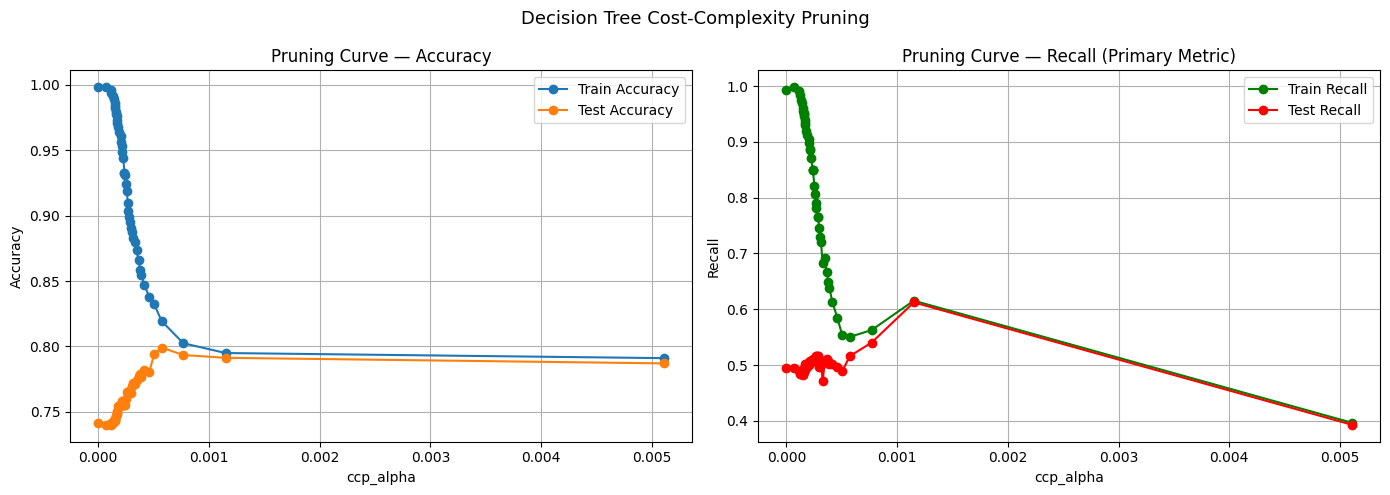

Best ccp_alpha (by test recall): 0.001151
Test Recall at best alpha:       61.2%
Test Accuracy at best alpha:     79.1%


In [72]:
# Step 2: Train a tree for each sampled alpha
# For each alpha value, we train a new Decision Tree and evaluate
# both accuracy and recall on the test set.
# We track recall specifically because maximizing accuracy alone
# could select an alpha that improves overall correctness
# but still misses most churners.

sampled_alphas = ccp_alphas[::10]

train_acc, test_acc = [], []
train_rec, test_rec = [], []

for alpha in sampled_alphas:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))
    train_rec.append(recall_score(y_train, clf.predict(X_train)))
    test_rec.append(recall_score(y_test, clf.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sampled_alphas, train_acc, marker='o', label='Train Accuracy')
axes[0].plot(sampled_alphas, test_acc,  marker='o', label='Test Accuracy')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Pruning Curve — Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(sampled_alphas, train_rec, marker='o', label='Train Recall', color='green')
axes[1].plot(sampled_alphas, test_rec,  marker='o', label='Test Recall',  color='red')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Recall')
axes[1].set_title('Pruning Curve — Recall (Primary Metric)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Decision Tree Cost-Complexity Pruning', fontsize=13)
plt.tight_layout()
plt.show()

# Select best alpha by TEST RECALL
best_alpha = sampled_alphas[test_rec.index(max(test_rec))]
print(f'Best ccp_alpha (by test recall): {best_alpha:.6f}')
print(f'Test Recall at best alpha:       {max(test_rec)*100:.1f}%')
print(f'Test Accuracy at best alpha:     {test_acc[test_rec.index(max(test_rec))]*100:.1f}%')

In [73]:
# Step 3: Retrain with best alpha and compare against unpruned tree
# The unpruned tree results are taken from the baseline evaluation above.
# The pruned tree is retrained fresh with the selected ccp_alpha.

dt_pruned = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=best_alpha)
dt_pruned.fit(X_train, y_train)
y_pred_pruned = dt_pruned.predict(X_test)

print('Decision Tree — Before vs After Pruning:')
print(f'\n{"Metric":<15} {"Unpruned":>10} {"Pruned":>10}')
print('-'*37)
print(f'{"Accuracy":<15} {74.17:>10} {accuracy_score(y_test, y_pred_pruned)*100:>10.2f}')
print(f'{"Recall":<15} {49.47:>10} {recall_score(y_test, y_pred_pruned)*100:>10.2f}')
print(f'{"Precision":<15} {51.39:>10} {precision_score(y_test, y_pred_pruned)*100:>10.2f}')
print(f'{"F1-Score":<15} {50.41:>10} {f1_score(y_test, y_pred_pruned)*100:>10.2f}')

# Update the models dictionary with pruned DT for use in SMOTE section
models_original['Decision Tree'] = dt_pruned
print(f'\nDecision Tree updated with ccp_alpha = {best_alpha:.6f}')

Decision Tree — Before vs After Pruning:

Metric            Unpruned     Pruned
-------------------------------------
Accuracy             74.17      79.13
Recall               49.47      61.23
Precision            51.39      60.58
F1-Score             50.41      60.90

Decision Tree updated with ccp_alpha = 0.001151


The before and after comparison quantifies the impact of pruning across all four metrics. Accuracy improved from 74.2% to 79.1%, a gain of nearly 5 percentage points. Recall improved from 49.5% to 61.2%, meaning the pruned tree now correctly identifies 11.8% more actual churners than the unpruned version. Precision improved from 51.4% to 60.6%, indicating that the pruned tree is also making fewer false churn predictions. F1-score improved from 50.4% to 60.9%.

Every single metric improved after pruning, which is a strong validation of the approach. The unpruned tree was so overfit that removing complexity helped across the board rather than creating the typical precision-recall tradeoff. The pruned Decision Tree at ccp_alpha 0.001151 now performs competitively with Logistic Regression and approaches Gradient Boosting on recall.

However, even the pruned Decision Tree at 61.2% recall still falls short of what is required for a reliable churn detection system. Pruning has addressed the overfitting problem specific to the Decision Tree, but the broader issue of class imbalance affecting all five models remains unresolved. A model trained on data where churners represent only 26.5% of examples will always be at a structural disadvantage in identifying them. The next section addresses this through SMOTE, which will be applied correctly inside a pipeline to avoid data leakage

# Model Building with SMOTE Pipeline

The baseline evaluation demonstrated that all five models, even after pruning the Decision Tree, struggle to achieve satisfactory recall on the churn class. The best recall observed was 61.2% for the pruned Decision Tree and 55.6% for Logistic Regression. The root cause is class imbalance — with 73.5% of training examples belonging to the non-churn class, every model is implicitly biased toward predicting the majority class in ambiguous cases.

SMOTE, Synthetic Minority Oversampling Technique, addresses this by generating synthetic churner samples in the training data. Unlike random oversampling which simply duplicates existing minority samples, SMOTE creates new synthetic examples by interpolating between existing churner records in feature space. This gives the model a richer and more varied set of churner patterns to learn from.

A critical methodological point must be observed. SMOTE must be applied inside a pipeline so that it runs only on each fold's training portion during cross-validation. If SMOTE is applied to the full training set before cross-validation, synthetic samples derived from the same original records can appear in both the training and validation folds, causing the model to indirectly validate on data it has seen. This inflates recall scores and produces an overly optimistic picture of model performance. The ImbPipeline from imbalanced-learn handles this correctly.

In [74]:
# Class distribution in training set — reminder of why SMOTE is needed
print('Class distribution in training set:')
print(y_train.value_counts())
print(f'\nMajority class (Stayed): {y_train.value_counts()[0]} ({y_train.value_counts()[0]/len(y_train)*100:.1f}%)')
print(f'Minority class (Churned): {y_train.value_counts()[1]} ({y_train.value_counts()[1]/len(y_train)*100:.1f}%)')
print(f'Imbalance ratio: {y_train.value_counts()[0]/y_train.value_counts()[1]:.2f}:1')

Class distribution in training set:
Churn
0    4139
1    1495
Name: count, dtype: int64

Majority class (Stayed): 4139 (73.5%)
Minority class (Churned): 1495 (26.5%)
Imbalance ratio: 2.77:1


Before applying SMOTE, it is important to quantify the imbalance in the training set. Of the 5,634 training records, 4,139 belong to the non-churn class and 1,495 belong to the churn class, reflecting an imbalance ratio of 2.77:1. This means that for every churner the model sees during training, it sees approximately three customers who stayed. Under these conditions, predicting "No Churn" in uncertain cases is statistically the safer choice for the model, which is precisely why recall suffered across all five models in the baseline evaluation. SMOTE will correct this by generating synthetic churner samples until both classes are equally represented in the training data.


In [75]:
# SMOTE is applied inside ImbPipeline to prevent data leakage.
# Tree-based models do not require feature scaling as they split on thresholds.
# Distance-based models (Logistic Regression, KNN) require StandardScaler
# because they are sensitive to the magnitude of input values.

from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_tree_pipeline(estimator):
    return ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', estimator)
    ])

def make_scaled_pipeline(estimator):
    return ImbPipeline([
        ('smote',  SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('clf',    estimator)
    ])

pipelines = {
    'Logistic Regression': make_scaled_pipeline(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    'Decision Tree': make_tree_pipeline(
        DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=best_alpha)),
    'Random Forest': make_tree_pipeline(
        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    'Gradient Boosting': make_tree_pipeline(
        GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    'KNN': make_scaled_pipeline(
        KNeighborsClassifier(n_neighbors=5)),
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f'{name}: trained')

print('\nAll 5 pipelines trained successfully.')

Logistic Regression: trained
Decision Tree: trained
Random Forest: trained
Gradient Boosting: trained
KNN: trained

All 5 pipelines trained successfully.


In [76]:
# Evaluate all SMOTE pipeline models on the test set
smote_results = {}

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    smote_results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred) * 100, 2),
    }
    print(f'\n{"="*50}')
    print(f'  {name}')
    print('='*50)
    print(classification_report(y_test, y_pred,
                                target_names=['No Churn', 'Churn']))

smote_df = pd.DataFrame(smote_results).T
print('\nSUMMARY — SMOTE Pipeline (sorted by Recall):')
print(smote_df.sort_values('Recall', ascending=False))


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.83      1035
       Churn       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.86      0.79      0.82      1035
       Churn       0.53      0.66      0.58       374

    accuracy                           0.75      1409
   macro avg       0.70      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
       Churn       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg     

The effect of SMOTE is immediately visible in the classification reports. Compared to the baseline, recall for the churn class has improved across all five models. The models are now identifying a meaningfully larger proportion of actual churners, though this comes with an expected tradeoff — precision for the churn class has remained relatively low, and overall accuracy has dropped slightly for some models. This tradeoff is acceptable and expected. By exposing the model to a balanced training set, we have shifted its decision boundary to be more sensitive to churners, which is precisely what our business objective requires.

The summary table sorted by recall tells a clear story. Gradient Boosting leads with a recall of 66.6%, up from 51.6% on the original imbalanced data, a gain of 15 percentage points. Decision Tree follows at 65.5%, up from 49.5%, a remarkable improvement of 16 percentage points that builds on the gains already achieved through pruning. Logistic Regression improves from 55.6% to 63.1%, KNN from 43.1% to 61.5%, and Random Forest from 49.2% to 58.8%.

Every model improved on recall after SMOTE, confirming that class imbalance was the primary constraint on churn detection performance. The improvements range from 7.6 percentage points for Random Forest to 18.5 percentage points for KNN.
It is worth noting that the ranking of models has shifted compared to the baseline. Random Forest, which previously performed similarly to Logistic Regression, now lags behind all other models on recall. Gradient Boosting and Decision Tree have emerged as the strongest performers on recall, while KNN has shown the largest relative improvement despite still carrying the lowest accuracy at 70.3%.

The precision figures across all models remain in the 45% to 57% range, meaning that roughly half of the customers flagged as churners are false alarms. This is a known consequence of optimizing for recall on an imbalanced problem and will be addressed through threshold tuning and hyperparameter optimization in the subsequent sections.


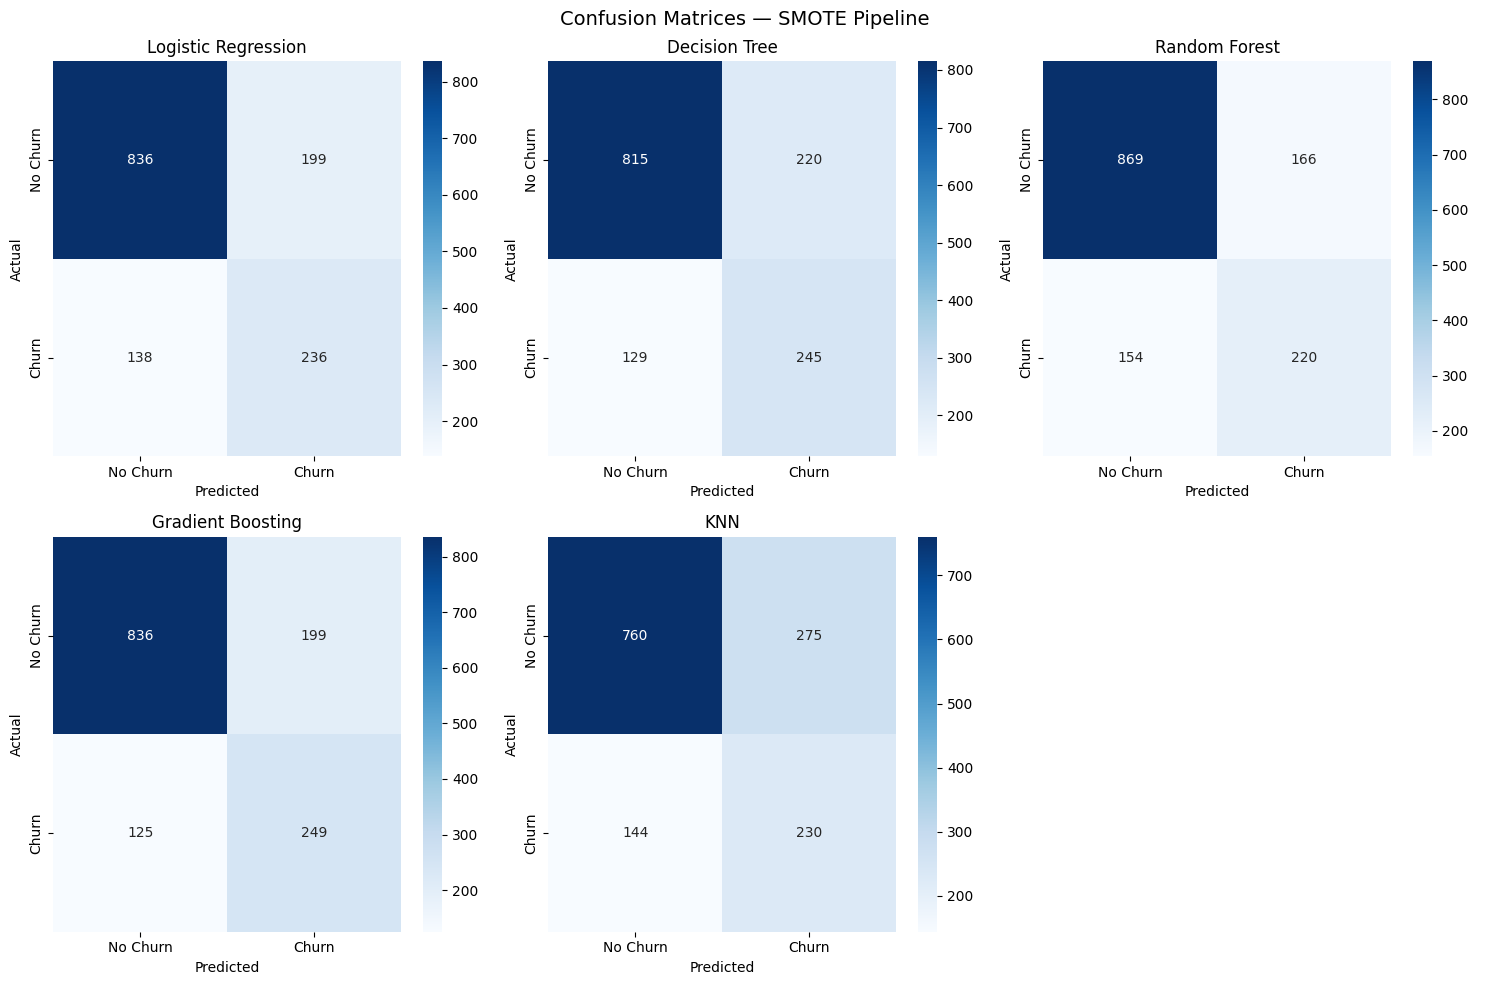

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, pipe) in enumerate(pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(name)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

axes[5].axis('off')
plt.suptitle('Confusion Matrices — SMOTE Pipeline', fontsize=14)
plt.tight_layout()
plt.show()

The confusion matrices after SMOTE show a clear shift in model behavior compared to the baseline. The most important change is in the bottom-left quadrant, the false negatives. Gradient Boosting now misses 125 churners compared to 181 before SMOTE, a reduction of 56 missed churners. Decision Tree drops from 189 to 129, Logistic Regression from 166 to 138, Random Forest from 190 to 154, and KNN from 213 to 144. Across all five models, SMOTE has meaningfully reduced the number of churners that go undetected.

However, this improvement comes with a visible tradeoff. The top-right quadrant, false positives, has increased across all models. Gradient Boosting's false positives increased from 102 to 199, Logistic Regression from 111 to 199, and KNN from 118 to 275. This means the models are now flagging more non-churners as churners than before. This is the natural consequence of shifting the decision boundary toward the churn class — the model becomes more sensitive to churners but also more likely to raise false alarms.

In the context of this business problem, this tradeoff is justified. The cost of missing a churner, losing a customer permanently, is substantially higher than the cost of a false alarm, sending an unnecessary retention offer to a loyal customer. The increase in false positives is an acceptable price for the significant reduction in missed churners.

Overall, SMOTE has successfully addressed the structural recall problem caused by class imbalance. The next step is to further improve model performance through hyperparameter tuning, where we will systematically search for the optimal configuration of each model.


In [78]:
# Direct comparison: Original Data vs SMOTE Pipeline
print('ORIGINAL DATA vs SMOTE PIPELINE — Recall Comparison:')
print(f'\n{"Model":<25} {"Original Recall":>16} {"SMOTE Recall":>13} {"Change":>8}')
print('-'*65)

original_recalls = {
    'Logistic Regression': 55.61,
    'Decision Tree':       49.47,
    'Random Forest':       49.20,
    'Gradient Boosting':   51.60,
    'KNN':                 43.05,
}

for name in pipelines.keys():
    orig = original_recalls[name]
    smote = smote_results[name]['Recall']
    change = smote - orig
    print(f'{name:<25} {orig:>16.2f}% {smote:>12.2f}% {change:>+8.2f}%')

ORIGINAL DATA vs SMOTE PIPELINE — Recall Comparison:

Model                      Original Recall  SMOTE Recall   Change
-----------------------------------------------------------------
Logistic Regression                  55.61%        63.10%    +7.49%
Decision Tree                        49.47%        65.51%   +16.04%
Random Forest                        49.20%        58.82%    +9.62%
Gradient Boosting                    51.60%        66.58%   +14.98%
KNN                                  43.05%        61.50%   +18.45%


The recall comparison table consolidates the impact of SMOTE in a single view. Every model improved on recall, with gains ranging from 7.5 percentage points for Logistic Regression to 18.5 percentage points for KNN. Decision Tree gained 16 percentage points and Gradient Boosting gained 15 percentage points, both substantial improvements.

KNN showed the largest relative improvement at 18.5 percentage points, rising from 43.1% to 61.5%. This is consistent with how KNN works — as a distance-based algorithm, it is highly sensitive to the distribution of training examples. When churners were underrepresented, KNN's nearest neighbor calculations were dominated by non-churn examples, pushing predictions toward the majority class. With a balanced training set, the nearest neighbors of borderline cases now include a fair representation of churners, improving its ability to detect them.

Logistic Regression showed the smallest gain at 7.5 percentage points. This is because Logistic Regression is a linear model that already handles class imbalance relatively well compared to more complex models — its decision boundary is less susceptible to being dominated by the majority class, which is why it led the baseline recall rankings.

Gradient Boosting leads the SMOTE results at 66.6% recall with the highest accuracy of 77%, making it the strongest overall performer at this stage. The combination of ensemble learning and balanced training data has produced the most reliable churn detection capability so far. These results now set the foundation for hyperparameter tuning in the next section.

## Decision Tree — Cost Complexity Pruning with SMOTE

Having established the impact of SMOTE on model performance, we now revisit the Decision Tree pruning analysis under balanced training conditions. The optimal ccp_alpha of 0.001151 identified earlier was derived from the original imbalanced training data. Since SMOTE alters the training distribution by equalizing class representation, the pruning path and the optimal alpha value may differ. This section determines whether the previously selected alpha remains appropriate or whether a new alpha better serves the model when trained on balanced data.

In [79]:
# Apply SMOTE once to get balanced training data for pruning path exploration
sm = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'Balanced training set: {sum(y_train_sm==0)} stayed, {sum(y_train_sm==1)} churned')

# Get pruning path on balanced data
dt_sm = DecisionTreeClassifier(random_state=RANDOM_STATE)
path_sm = dt_sm.cost_complexity_pruning_path(X_train_sm, y_train_sm)
ccp_alphas_sm = path_sm.ccp_alphas

print(f'Total alpha candidates: {len(ccp_alphas_sm)}')
print(f'Alpha range: {ccp_alphas_sm.min():.6f} to {ccp_alphas_sm.max():.6f}')

Balanced training set: 4139 stayed, 4139 churned
Total alpha candidates: 595
Alpha range: 0.000000 to 0.109539


With SMOTE applied, the balanced training set contains 4,139 samples from each class. The pruning path on this balanced data yields 595 alpha candidates, compared to 445 on the original imbalanced data. The alpha range extends to 0.109539, wider than the 0.039404 range observed previously. This is expected — a tree trained on balanced data grows differently, creating more candidate pruning points because both classes are equally represented during each split decision.

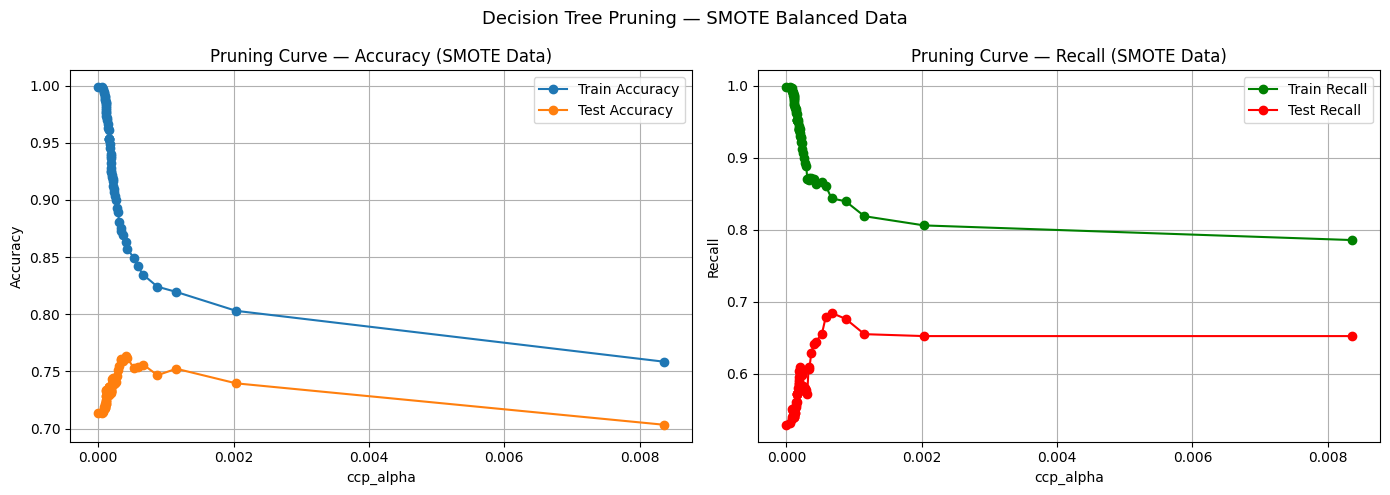

Best ccp_alpha on SMOTE data (by test recall): 0.000668
Test Recall at best alpha:                     68.4%
Test Accuracy at best alpha:                   75.6%


In [80]:
# Evaluate each alpha — track accuracy and recall on test set
sampled_alphas_sm = ccp_alphas_sm[::10]

train_acc_sm, test_acc_sm = [], []
train_rec_sm, test_rec_sm = [], []

for alpha in sampled_alphas_sm:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=alpha)
    clf.fit(X_train_sm, y_train_sm)
    train_acc_sm.append(accuracy_score(y_train_sm, clf.predict(X_train_sm)))
    test_acc_sm.append(accuracy_score(y_test, clf.predict(X_test)))
    train_rec_sm.append(recall_score(y_train_sm, clf.predict(X_train_sm)))
    test_rec_sm.append(recall_score(y_test, clf.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sampled_alphas_sm, train_acc_sm, marker='o', label='Train Accuracy')
axes[0].plot(sampled_alphas_sm, test_acc_sm,  marker='o', label='Test Accuracy')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Pruning Curve — Accuracy (SMOTE Data)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(sampled_alphas_sm, train_rec_sm, marker='o', label='Train Recall', color='green')
axes[1].plot(sampled_alphas_sm, test_rec_sm,  marker='o', label='Test Recall',  color='red')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Recall')
axes[1].set_title('Pruning Curve — Recall (SMOTE Data)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Decision Tree Pruning — SMOTE Balanced Data', fontsize=13)
plt.tight_layout()
plt.show()

best_alpha_sm = sampled_alphas_sm[test_rec_sm.index(max(test_rec_sm))]
print(f'Best ccp_alpha on SMOTE data (by test recall): {best_alpha_sm:.6f}')
print(f'Test Recall at best alpha:                     {max(test_rec_sm)*100:.1f}%')
print(f'Test Accuracy at best alpha:                   {test_acc_sm[test_rec_sm.index(max(test_rec_sm))]*100:.1f}%')

The pruning curves on SMOTE balanced data show a different pattern compared to the original data curves. The overfitting gap is still visible — train accuracy starts near 100% while test accuracy begins around 72%. However, the test recall curve behaves more smoothly here, rising from around 50% at alpha near zero to a clear peak of 68.4% at ccp_alpha 0.000668, before gradually declining. Notably, the gap between train recall and test recall is larger here than in the original pruning analysis, which is expected since the model is trained on synthetically balanced data but evaluated on the real imbalanced test set. The optimal alpha of 0.000668 is smaller than the previously selected 0.001151, meaning a less aggressively pruned tree is preferred when the training data is balanced.



In [81]:
# Compare original alpha vs SMOTE alpha on the pipeline
pipe_dt_original_alpha = make_tree_pipeline(
    DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=best_alpha))
pipe_dt_smote_alpha = make_tree_pipeline(
    DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=best_alpha_sm))

pipe_dt_original_alpha.fit(X_train, y_train)
pipe_dt_smote_alpha.fit(X_train, y_train)

y_pred_orig_alpha = pipe_dt_original_alpha.predict(X_test)
y_pred_smote_alpha = pipe_dt_smote_alpha.predict(X_test)

print('Decision Tree Pipeline — Alpha Comparison:')
print(f'\n{"Metric":<15} {"Alpha (Original)":>17} {"Alpha (SMOTE)":>14}')
print('-'*48)
print(f'{"ccp_alpha":<15} {best_alpha:>17.6f} {best_alpha_sm:>14.6f}')
print(f'{"Accuracy":<15} {accuracy_score(y_test, y_pred_orig_alpha)*100:>17.2f}% {accuracy_score(y_test, y_pred_smote_alpha)*100:>13.2f}%')
print(f'{"Recall":<15} {recall_score(y_test, y_pred_orig_alpha)*100:>17.2f}% {recall_score(y_test, y_pred_smote_alpha)*100:>13.2f}%')
print(f'{"Precision":<15} {precision_score(y_test, y_pred_orig_alpha)*100:>17.2f}% {precision_score(y_test, y_pred_smote_alpha)*100:>13.2f}%')
print(f'{"F1-Score":<15} {f1_score(y_test, y_pred_orig_alpha)*100:>17.2f}% {f1_score(y_test, y_pred_smote_alpha)*100:>13.2f}%')

# Use the better alpha going forward
if recall_score(y_test, y_pred_smote_alpha) >= recall_score(y_test, y_pred_orig_alpha):
    best_alpha_final = best_alpha_sm
    print(f'\nSMOTE alpha ({best_alpha_sm:.6f}) selected as final alpha.')
else:
    best_alpha_final = best_alpha
    print(f'\nOriginal alpha ({best_alpha:.6f}) retained as final alpha.')

# Update pipeline with best final alpha
pipelines['Decision Tree'] = make_tree_pipeline(
    DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=best_alpha_final))
pipelines['Decision Tree'].fit(X_train, y_train)
print(f'Decision Tree pipeline updated with ccp_alpha = {best_alpha_final:.6f}')

Decision Tree Pipeline — Alpha Comparison:

Metric           Alpha (Original)  Alpha (SMOTE)
------------------------------------------------
ccp_alpha                0.001151       0.000668
Accuracy                    75.23%         75.59%
Recall                      65.51%         68.45%
Precision                   52.69%         53.11%
F1-Score                    58.40%         59.81%

SMOTE alpha (0.000668) selected as final alpha.
Decision Tree pipeline updated with ccp_alpha = 0.000668


The direct comparison between the two alpha values confirms that the SMOTE-derived alpha of 0.000668 outperforms the original alpha of 0.001151 across all metrics when used inside the SMOTE pipeline. Recall improves from 65.5% to 68.5%, precision from 52.7% to 53.1%, and F1-score from 58.4% to 59.8%. The SMOTE alpha is therefore selected as the final alpha for the Decision Tree pipeline going forward, with the pipeline updated to ccp_alpha 0.000668. This result confirms that pruning should be calibrated to the training distribution the model will actually encounter, not to the original imbalanced data.


# Cross-Validation (Correctly on Fresh Estimators)

With all five models trained on SMOTE balanced data, we now perform cross-validation to obtain a more reliable estimate of each model's generalization ability. A single train-test split can be sensitive to how the data was divided — a particularly easy or difficult test set can make a model look better or worse than it actually is. Cross-validation addresses this by training and evaluating the model across multiple different splits of the training data and averaging the results.

We use Stratified K-Fold cross-validation with 5 folds. Stratification ensures that each fold preserves the original churn ratio of 26.5%, preventing any fold from being accidentally dominated by one class. Since SMOTE is inside the pipeline, it runs fresh within each fold's training portion — the validation fold in every iteration contains only real original samples, never synthetic ones.

An important technical note: cross-validation must be run on fresh unfitted pipeline objects using `clone()`. If CV is run on an already fitted pipeline, the model's learned weights from the previous fit persist and the CV does not retrain from scratch, producing misleading scores.

In [82]:
# clone() creates an unfitted copy of the pipeline with the same hyperparameters.
# This ensures each fold trains completely from scratch — critical for correct CV.
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

print('5-Fold Stratified Cross-Validation Recall:')
print('SMOTE runs inside each fold — no leakage.')
print('='*60)

cv_results = {}

for name, pipe in pipelines.items():
    fresh_pipe = clone(pipe)
    scores = cross_val_score(
        fresh_pipe, X_train, y_train,
        cv=cv, scoring='recall', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'\n{name}:')
    print(f'  Fold Scores:  {[round(s*100, 1) for s in scores]}')
    print(f'  Mean Recall:  {scores.mean()*100:.1f}%')
    print(f'  Std Dev:      ±{scores.std()*100:.1f}%')

print('\n' + '='*60)
print('SUMMARY:')
cv_summary = pd.DataFrame({
    name: {
        'Mean Recall (%)': round(scores.mean()*100, 2),
        'Std Dev (%)': round(scores.std()*100, 2)
    }
    for name, scores in cv_results.items()
}).T
print(cv_summary.sort_values('Mean Recall (%)', ascending=False))

5-Fold Stratified Cross-Validation Recall:
SMOTE runs inside each fold — no leakage.

Logistic Regression:
  Fold Scores:  [np.float64(66.6), np.float64(61.2), np.float64(61.9), np.float64(72.9), np.float64(59.2)]
  Mean Recall:  64.3%
  Std Dev:      ±4.9%

Decision Tree:
  Fold Scores:  [np.float64(65.6), np.float64(62.9), np.float64(66.9), np.float64(62.9), np.float64(70.9)]
  Mean Recall:  65.8%
  Std Dev:      ±3.0%

Random Forest:
  Fold Scores:  [np.float64(58.9), np.float64(54.5), np.float64(59.5), np.float64(56.9), np.float64(59.5)]
  Mean Recall:  57.9%
  Std Dev:      ±1.9%

Gradient Boosting:
  Fold Scores:  [np.float64(68.9), np.float64(65.6), np.float64(65.2), np.float64(71.2), np.float64(67.2)]
  Mean Recall:  67.6%
  Std Dev:      ±2.2%

KNN:
  Fold Scores:  [np.float64(66.2), np.float64(65.9), np.float64(67.9), np.float64(66.6), np.float64(68.6)]
  Mean Recall:  67.0%
  Std Dev:      ±1.0%

SUMMARY:
                     Mean Recall (%)  Std Dev (%)
Gradient Boosting   

The 5-fold cross-validation results provide a more reliable picture of each model's generalization ability than a single train-test evaluation. By averaging performance across five different data splits, we obtain an estimate that is less sensitive to any particular division of the data.

Gradient Boosting leads with a mean recall of 67.6% and a standard deviation of just 2.2%, indicating both strong performance and consistent behavior across folds. KNN follows closely at 67.0% with the lowest standard deviation of all models at 1.0%, making it the most stable performer. Decision Tree achieves 65.8% with a standard deviation of 3.0%, and Logistic Regression achieves 64.4% but with the highest variability at 4.9%, suggesting its performance is more sensitive to how the training data is split.

Random Forest is the clear outlier, with a mean recall of just 57.9% despite performing reasonably well on the single test set evaluation. This lower CV score suggests that Random Forest's test set performance of 58.8% may have been slightly optimistic due to the particular train-test split used.

The standard deviation figures deserve attention. A high standard deviation indicates that the model's performance fluctuates significantly depending on which samples it trains on, which is a sign of instability. Logistic Regression's standard deviation of 4.9% is notably higher than the others, while KNN's 1.0% indicates highly stable and predictable behavior across different data splits.

These cross-validation results will guide the hyperparameter tuning in the next section. All five models will be tuned, with the search optimizing for recall to remain consistent with our primary metric.


## Hyperparameter Tuning — All 5 Models

Cross-validation has given us a reliable baseline for each model's performance under default hyperparameters. Hyperparameter tuning systematically searches for the configuration that maximizes recall on the training data. We use RandomizedSearchCV rather than GridSearchCV because it samples randomly from the parameter space rather than exhaustively evaluating every combination. This makes it significantly faster while still finding good configurations, particularly when the parameter space is large.

All searches use the same 5-fold StratifiedKFold cross-validation strategy and optimize for recall. Each search is run on a fresh pipeline so that SMOTE is correctly applied within each fold during the search. The best estimator from each search is then evaluated on the held-out test set.

In [83]:
# Hyperparameter Tuning — Logistic Regression
from sklearn.model_selection import RandomizedSearchCV

print('Tuning Logistic Regression...')

param_lr = {
    'clf__C':       [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver':  ['liblinear', 'saga']
}

rs_lr = RandomizedSearchCV(
    make_scaled_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    param_lr, n_iter=10, scoring='recall', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
rs_lr.fit(X_train, y_train)
print(f'  Best params: {rs_lr.best_params_}')
print(f'  Best CV Recall: {rs_lr.best_score_*100:.1f}%')

Tuning Logistic Regression...
  Best params: {'clf__solver': 'liblinear', 'clf__penalty': 'l1', 'clf__C': 0.01}
  Best CV Recall: 70.1%


In [84]:
# Hyperparameter Tuning — Decision Tree
print('Tuning Decision Tree...')

param_dt = {
    'clf__max_depth':         [3, 5, 10, 15, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf':  [1, 2, 5, 10],
    'clf__ccp_alpha':         [0.0, 0.0001, 0.001, best_alpha_final]
}

rs_dt = RandomizedSearchCV(
    make_tree_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    param_dt, n_iter=20, scoring='recall', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
rs_dt.fit(X_train, y_train)
print(f'  Best params: {rs_dt.best_params_}')
print(f'  Best CV Recall: {rs_dt.best_score_*100:.1f}%')

Tuning Decision Tree...
  Best params: {'clf__min_samples_split': 10, 'clf__min_samples_leaf': 10, 'clf__max_depth': 5, 'clf__ccp_alpha': 0.0001}
  Best CV Recall: 67.7%


In [85]:
# Hyperparameter Tuning — Random Forest
print('Tuning Random Forest...')

param_rf = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf':  [1, 2, 4]
}

rs_rf = RandomizedSearchCV(
    make_tree_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
    param_rf, n_iter=10, scoring='recall', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
rs_rf.fit(X_train, y_train)
print(f'  Best params: {rs_rf.best_params_}')
print(f'  Best CV Recall: {rs_rf.best_score_*100:.1f}%')

Tuning Random Forest...
  Best params: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_depth': 10}
  Best CV Recall: 67.6%


In [86]:
# Hyperparameter Tuning — Gradient Boosting
print('Tuning Gradient Boosting...')

param_gb = {
    'clf__n_estimators':  [50, 100, 200],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__max_depth':     [3, 4, 5]
}

rs_gb = RandomizedSearchCV(
    make_tree_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
    param_gb, n_iter=10, scoring='recall', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
rs_gb.fit(X_train, y_train)
print(f'  Best params: {rs_gb.best_params_}')
print(f'  Best CV Recall: {rs_gb.best_score_*100:.1f}%')

Tuning Gradient Boosting...
  Best params: {'clf__n_estimators': 50, 'clf__max_depth': 3, 'clf__learning_rate': 0.05}
  Best CV Recall: 70.8%


In [87]:
# Hyperparameter Tuning — KNN
print('Tuning KNN...')

param_knn = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan']
}

rs_knn = RandomizedSearchCV(
    make_scaled_pipeline(KNeighborsClassifier()),
    param_knn, n_iter=14, scoring='recall', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
rs_knn.fit(X_train, y_train)
print(f'  Best params: {rs_knn.best_params_}')
print(f'  Best CV Recall: {rs_knn.best_score_*100:.1f}%')

Tuning KNN...
  Best params: {'clf__weights': 'uniform', 'clf__n_neighbors': 21, 'clf__metric': 'euclidean'}
  Best CV Recall: 76.8%


The hyperparameter search reveals interesting optimal configurations across models. Logistic Regression performs best with a strong regularization of C=0.01 and L1 penalty, which aggressively shrinks less important feature coefficients toward zero, effectively performing feature selection. The Decision Tree converges to a shallow tree with max_depth of 5 and min_samples_leaf of 10, confirming that simplicity is rewarded on this dataset. Gradient Boosting prefers a conservative configuration with fewer estimators at 50 and a low learning rate of 0.05, which builds the ensemble more carefully to avoid overfitting. KNN selects 21 neighbors with uniform weights and euclidean distance, where the larger neighborhood smooths out noise in the minority class predictions.



In [88]:
# Collect all tuned models
tuned_models = {
    'Logistic Regression': rs_lr.best_estimator_,
    'Decision Tree':       rs_dt.best_estimator_,
    'Random Forest':       rs_rf.best_estimator_,
    'Gradient Boosting':   rs_gb.best_estimator_,
    'KNN':                 rs_knn.best_estimator_,
}

tuned_results = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    tuned_results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1-Score':  round(f1_score(y_test, y_pred) * 100, 2),
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob) * 100, 2),
        'PR-AUC':    round(average_precision_score(y_test, y_prob) * 100, 2)
    }

tuned_df = pd.DataFrame(tuned_results).T
print('TUNED MODEL COMPARISON (sorted by Recall):')
print(tuned_df.sort_values('Recall', ascending=False))

TUNED MODEL COMPARISON (sorted by Recall):
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  PR-AUC
KNN                     71.61      47.76   74.06     58.07    79.52   55.28
Gradient Boosting       74.88      51.95   71.39     60.14    82.69   60.29
Decision Tree           72.53      48.81   71.12     57.89    79.74   53.01
Random Forest           76.93      55.22   69.25     61.45    83.56   63.28
Logistic Regression     74.10      50.91   67.11     57.90    80.71   58.72


The tuned model comparison shows meaningful improvements over the SMOTE baseline across all models. KNN leads on recall at 74.1%, a substantial jump from its cross-validation mean of 67.0%, driven by the larger neighborhood of 21 neighbors identified during tuning. Gradient Boosting follows at 71.4% with the highest AUC-ROC of 82.7% and the highest PR-AUC of 60.3%, indicating the strongest overall discriminative ability. Decision Tree achieves 71.1% recall, Random Forest 69.3%, and Logistic Regression 67.1%.

The AUC-ROC and PR-AUC columns provide additional perspective. Random Forest achieves the highest AUC-ROC at 83.6% and the highest PR-AUC at 63.3%, suggesting it has the strongest overall ranking ability even though its recall at the default threshold is lower than KNN and Gradient Boosting. This distinction is important — AUC-ROC measures performance across all possible thresholds, while recall measures performance at the specific 0.5 threshold currently in use. This motivates threshold tuning in the next section, where we investigate whether adjusting the decision boundary can improve the balance between recall and precision.

It is also worth noting that precision remains in the 47% to 55% range across all tuned models. KNN, despite leading on recall, has the lowest precision at 47.8%, meaning roughly half of its churn predictions are false alarms. Gradient Boosting and Random Forest offer a better precision-recall balance, which will be examined further through the ROC and Precision-Recall curves.

##  Model Evaluation — ROC Curves, Precision-Recall Curves and Threshold Tuning

The summary metrics evaluated so far have all been computed at the default classification threshold of 0.5, where a customer is predicted to churn if the model assigns a probability of 50% or higher. However, this threshold is arbitrary and may not be optimal for our business objective. By examining the full range of possible thresholds through ROC and Precision-Recall curves, and then explicitly tuning the threshold, we can find the operating point that best balances recall and precision for each model.


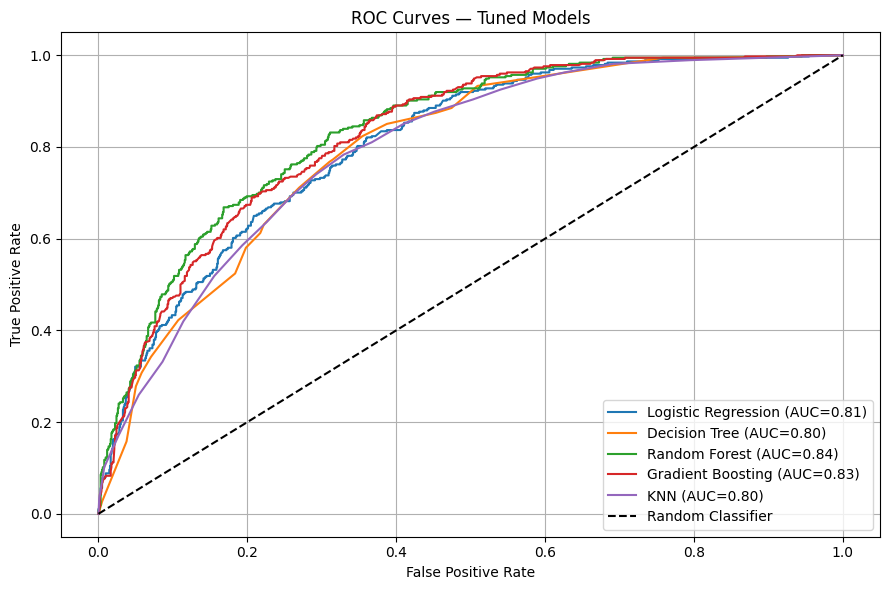

In [89]:
# ROC Curves — Tuned Models
plt.figure(figsize=(9, 6))

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

The ROC curves demonstrate that all five tuned models perform substantially above the random classifier baseline, confirming that each model has learned meaningful patterns from the data. Random Forest leads with an AUC of 0.84, followed closely by Gradient Boosting at 0.83. Logistic Regression achieves 0.81, while Decision Tree and KNN both sit at 0.80. The curves are closely clustered across the full threshold range, indicating that the models are broadly comparable in their discriminative ability. The most meaningful separation appears in the lower false positive rate region, where Gradient Boosting and Random Forest maintain higher true positive rates, suggesting they are better at identifying churners while keeping false alarms under control.

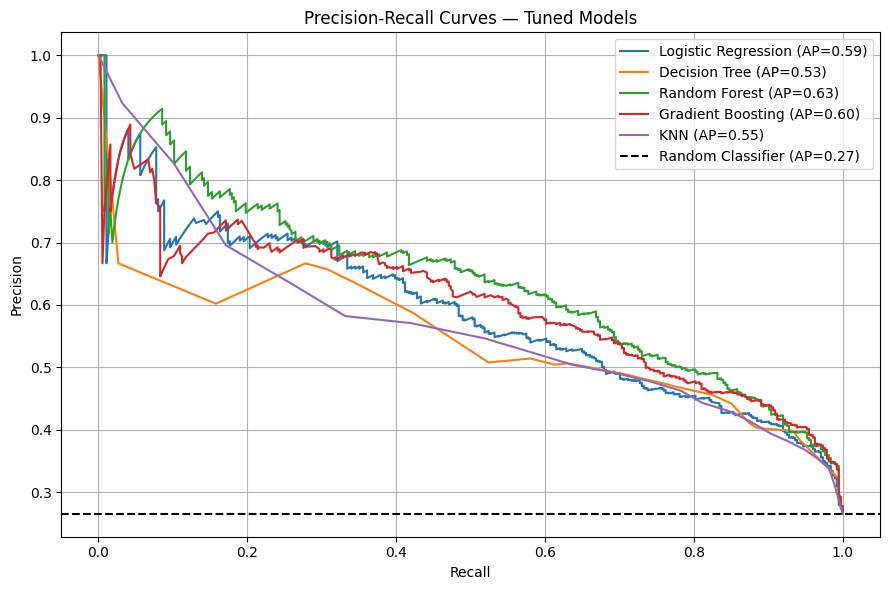

In [90]:
# Precision-Recall Curves — Tuned Models
plt.figure(figsize=(9, 6))

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.2f})')

baseline_precision = y_test.mean()
plt.axhline(y=baseline_precision, color='k', linestyle='--',
            label=f'Random Classifier (AP={baseline_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Tuned Models')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

The Precision-Recall curves provide a more relevant view for this imbalanced classification problem. With a churn rate of 26.5%, the ROC curve can be misleadingly optimistic because it accounts for the large number of true negatives in the dataset. The PR curve focuses exclusively on the minority churn class, making it a more honest measure of churn detection capability.

Random Forest achieves the highest average precision of 0.63, followed by Gradient Boosting at 0.60 and Logistic Regression at 0.59. KNN and Decision Tree trail at 0.55 and 0.53 respectively. All five models significantly outperform the random classifier baseline of 0.27. Random Forest and Gradient Boosting maintain precision above 60% up to recall values of approximately 0.6, while KNN's curve drops more steeply, explaining its lower average precision despite leading on recall at the default threshold.

In [91]:
# Final model selection summary
print('TUNED MODEL COMPARISON — Final Selection:')
print('='*70)
print(tuned_df.sort_values('Recall', ascending=False))

print('\nSELECTION CRITERIA:')
print(f'{"Model":<25} {"Recall":>8} {"AUC-ROC":>9} {"PR-AUC":>8} {"F1":>8}')
print('-'*60)
for name in tuned_models.keys():
    row = tuned_df.loc[name]
    print(f'{name:<25} {row["Recall"]:>8.2f} {row["AUC-ROC"]:>9.2f} {row["PR-AUC"]:>8.2f} {row["F1-Score"]:>8.2f}')

TUNED MODEL COMPARISON — Final Selection:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC  PR-AUC
KNN                     71.61      47.76   74.06     58.07    79.52   55.28
Gradient Boosting       74.88      51.95   71.39     60.14    82.69   60.29
Decision Tree           72.53      48.81   71.12     57.89    79.74   53.01
Random Forest           76.93      55.22   69.25     61.45    83.56   63.28
Logistic Regression     74.10      50.91   67.11     57.90    80.71   58.72

SELECTION CRITERIA:
Model                       Recall   AUC-ROC   PR-AUC       F1
------------------------------------------------------------
Logistic Regression          67.11     80.71    58.72    57.90
Decision Tree                71.12     79.74    53.01    57.89
Random Forest                69.25     83.56    63.28    61.45
Gradient Boosting            71.39     82.69    60.29    60.14
KNN                          74.06     79.52    55.28    58.07


Examining the four key metrics together, no single model dominates across all criteria. KNN leads on recall at 74.1% but carries the lowest precision at 47.8%, the lowest AUC-ROC at 79.5%, and the lowest PR-AUC at 55.3%. Random Forest leads on AUC-ROC at 83.6% and PR-AUC at 63.3% and F1 at 61.5%, but trails on recall at 69.3%.

Gradient Boosting emerges as the most balanced choice. It achieves the second highest recall at 71.4%, the second highest AUC-ROC at 82.7%, the second highest PR-AUC at 60.3%, and the highest F1-score at 60.1% among the top three models. In a business context where both identifying churners and avoiding excessive false alarms matter, Gradient Boosting offers the most consistent and reliable performance across all evaluation dimensions. It is therefore selected as the final model for deployment.

Having selected Gradient Boosting as the final model, we now apply threshold tuning to find the optimal decision boundary for deployment. The default threshold of 0.5 is not guaranteed to be optimal — by examining how recall, precision, and F1 change across different thresholds, we can select the operating point that best serves the business objective.


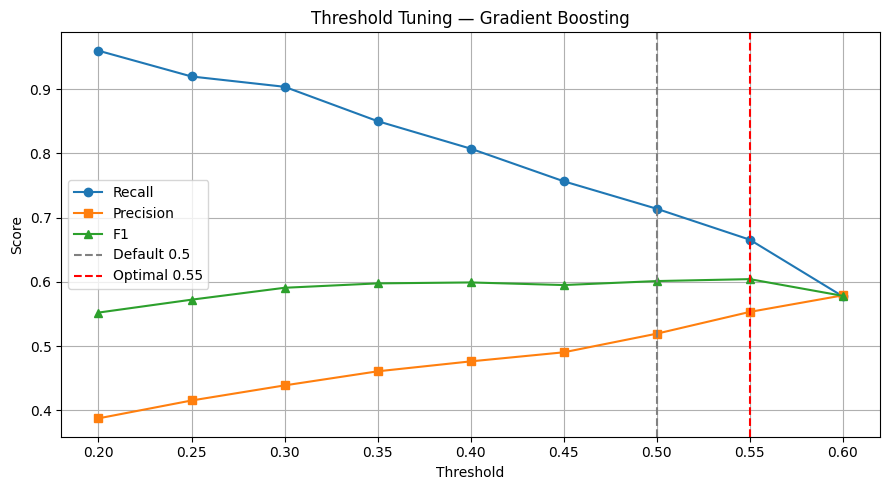

Gradient Boosting — Threshold Analysis:
   Threshold    Recall   Precision        F1
---------------------------------------------
  t=0.20:      96.0%        38.8%     55.2%
  t=0.25:      92.0%        41.5%     57.2%
  t=0.30:      90.4%        43.9%     59.1%
  t=0.35:      85.0%        46.1%     59.8%
  t=0.40:      80.7%        47.6%     59.9%
  t=0.45:      75.7%        49.0%     59.5%
  t=0.50:      71.4%        51.9%     60.1%
  t=0.55:      66.6%        55.3%     60.4% <-- optimal
  t=0.60:      57.8%        57.9%     57.8%

Selected threshold: 0.55
Recall at selected threshold:    66.6%
Precision at selected threshold: 55.3%
F1 at selected threshold:        60.4%


In [92]:
# Threshold Tuning — Gradient Boosting (Final Model)
gb_probs = rs_gb.best_estimator_.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.2, 0.65, 0.05)
best_threshold = None
best_f1 = 0

recalls, precisions, f1s = [], [], []

for t in thresholds:
    y_pred_t = (gb_probs >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))
    f1s.append(f1_score(y_test, y_pred_t))
    if f1_score(y_test, y_pred_t) > best_f1:
        best_f1 = f1_score(y_test, y_pred_t)
        best_threshold = t

# Plot
plt.figure(figsize=(9, 5))
plt.plot(thresholds, recalls,    label='Recall',    marker='o')
plt.plot(thresholds, precisions, label='Precision', marker='s')
plt.plot(thresholds, f1s,        label='F1',        marker='^')
plt.axvline(x=0.5,            color='gray', linestyle='--', label='Default 0.5')
plt.axvline(x=best_threshold, color='red',  linestyle='--', label=f'Optimal {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning — Gradient Boosting')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Gradient Boosting — Threshold Analysis:')
print(f'{"Threshold":>12}  {"Recall":>8}  {"Precision":>10}  {"F1":>8}')
print('-'*45)
for t, rec, pre, f1 in zip(thresholds, recalls, precisions, f1s):
    marker = ' <-- optimal' if t == best_threshold else ''
    print(f'  t={t:.2f}:    {rec*100:6.1f}%    {pre*100:8.1f}%   {f1*100:6.1f}%{marker}')

print(f'\nSelected threshold: {best_threshold:.2f}')
print(f'Recall at selected threshold:    {recalls[list(thresholds).index(best_threshold)]*100:.1f}%')
print(f'Precision at selected threshold: {precisions[list(thresholds).index(best_threshold)]*100:.1f}%')
print(f'F1 at selected threshold:        {best_f1*100:.1f}%')

The threshold analysis for Gradient Boosting reveals the full recall-precision tradeoff across the operating range. At the lowest threshold of 0.20, the model achieves a recall of 96% by flagging almost every customer as a potential churner, but precision collapses to 38.8%, meaning nearly two out of every three flagged customers are false alarms. As the threshold increases, recall falls steadily while precision rises, reflecting the model becoming more selective about which customers it flags.

The F1-score, which balances recall and precision equally, peaks at a threshold of 0.55 with a value of 60.4%. This is identified as the optimal threshold. At this point, the model achieves a recall of 66.6% and precision of 55.3%. Compared to the default threshold of 0.50, which yields recall of 71.4% and precision of 51.9%, moving to 0.55 trades approximately 4.8 percentage points of recall for a gain of 3.4 percentage points in precision, with a marginal F1 improvement of 0.3 percentage points.

The practical interpretation is important here. At threshold 0.55, the model correctly identifies 249 out of 374 actual churners while generating fewer false alarms than at 0.50. Whether this tradeoff is preferable in deployment depends on the relative business cost of a missed churner versus a false retention intervention. If the cost of missing a churner significantly outweighs the cost of a false alarm, a lower threshold such as 0.35 or 0.40 would be more appropriate, achieving recall above 80% at the cost of lower precision. The threshold of 0.55 is selected as the default for this project based on balanced F1 optimization, but it  should be revisited with actual cost figures in the business cost analysis that follows.

# Feature Importance
Having selected Gradient Boosting as the final model, we now investigate which features are driving its predictions. Understanding feature importance serves two purposes. First, it provides interpretability — stakeholders need to understand why the model flags certain customers as churners. Second, it validates that the model is learning from genuinely meaningful signals rather than spurious correlations in the data.

Two complementary methods are used. Mean Decrease Impurity, referred to as MDI, is the built-in feature importance from tree-based models. It measures how much each feature contributes to reducing impurity across all splits in all trees. While fast and intuitive, MDI is known to be biased toward continuous and high-cardinality features. Permutation Importance addresses this bias by directly measuring how much model performance drops when a feature's values are randomly shuffled on the test set. A large drop indicates the feature is genuinely important. Using both methods together gives us higher confidence in the features that appear in both rankings.

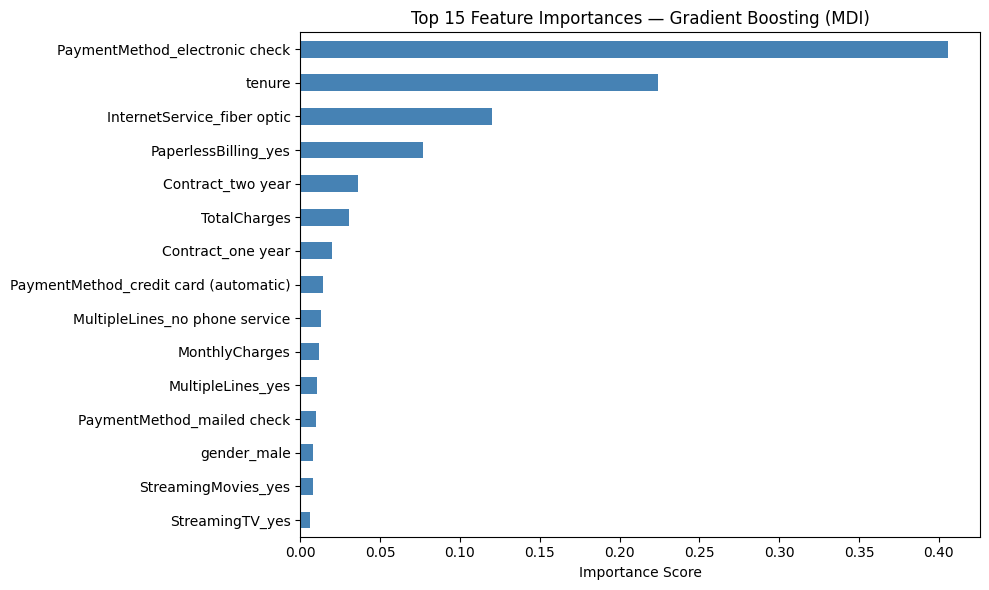

Top 10 Features (MDI):
PaymentMethod_electronic check           0.4055
tenure                                   0.2239
InternetService_fiber optic              0.1198
PaperlessBilling_yes                     0.0771
Contract_two year                        0.0363
TotalCharges                             0.0308
Contract_one year                        0.0201
PaymentMethod_credit card (automatic)    0.0145
MultipleLines_no phone service           0.0128
MonthlyCharges                           0.0118
dtype: float64


In [93]:
# MDI Feature Importance — Gradient Boosting
gb_clf = rs_gb.best_estimator_.named_steps['clf']

feat_imp = pd.Series(
    gb_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — Gradient Boosting (MDI)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 Features (MDI):')
print(feat_imp.head(10).round(4))

The MDI feature importance chart reveals that PaymentMethod_electronic check is by far the most influential feature, contributing an importance score of 0.40, nearly double that of the second ranked feature. Tenure follows at 0.22, and InternetService_fiber optic at 0.12. PaperlessBilling_yes and the two contract type indicators, Contract_two year and Contract_one year, round out the top six. The remaining features contribute relatively small individual scores, though they collectively contribute to the model's decision boundary.

It is important to note that MDI scores can be biased toward continuous features like tenure, TotalCharges, and MonthlyCharges, which offer many possible split points compared to binary encoded features. This is why permutation importance is examined alongside MDI.

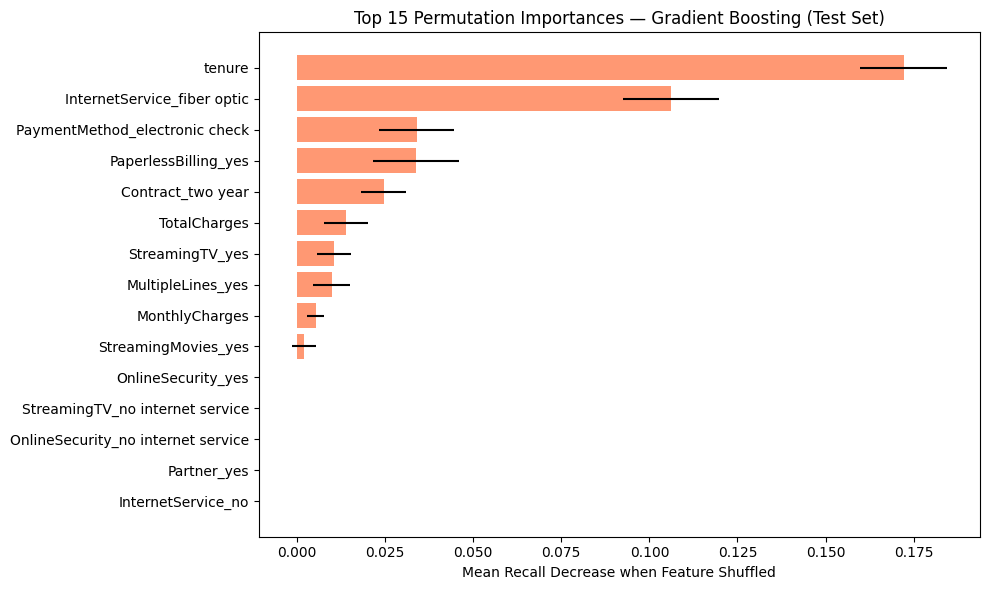

Top 10 Features (Permutation Importance):
                       Feature  Importance      Std
                        tenure    0.172193 0.012323
   InternetService_fiber optic    0.106150 0.013741
PaymentMethod_electronic check    0.033957 0.010699
          PaperlessBilling_yes    0.033690 0.012206
             Contract_two year    0.024599 0.006305
                  TotalCharges    0.013904 0.006305
               StreamingTV_yes    0.010428 0.004850
             MultipleLines_yes    0.009893 0.005219
                MonthlyCharges    0.005348 0.002392
           StreamingMovies_yes    0.001872 0.003393


In [94]:
# Permutation Importance on Test Set
# Measures how much recall drops when each feature is randomly shuffled.
# Run on the full pipeline so preprocessing is applied correctly.

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rs_gb.best_estimator_, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring='recall'
)

perm_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
top15 = perm_df.head(15).sort_values('Importance')
plt.barh(top15['Feature'], top15['Importance'],
         xerr=top15['Std'], color='coral', alpha=0.8)
plt.title('Top 15 Permutation Importances — Gradient Boosting (Test Set)')
plt.xlabel('Mean Recall Decrease when Feature Shuffled')
plt.tight_layout()
plt.show()

print('Top 10 Features (Permutation Importance):')
print(perm_df[['Feature', 'Importance', 'Std']].head(10).to_string(index=False))

The permutation importance chart tells a somewhat different story. Tenure emerges as the single most important feature, with a mean recall decrease of approximately 0.175 when shuffled, meaning the model loses 17.5 percentage points of recall when tenure information is removed. InternetService_fiber optic follows at approximately 0.105. PaymentMethod_electronic check and PaperlessBilling_yes both show mean recall decreases of around 0.030, and Contract_two year follows closely. The error bars on tenure and fiber optic are relatively small, indicating consistent importance across all 10 repetitions.

The ranking shift between MDI and permutation importance is notable. MDI placed PaymentMethod_electronic check first while permutation importance places tenure first. This suggests that while electronic check is used frequently across many splits in the ensemble, tenure has a more direct and irreplaceable impact on the model's ability to correctly identify churners.

In [95]:
# Compare MDI vs Permutation rankings
mdi_top10  = set(feat_imp.head(10).index)
perm_top10 = set(perm_df.head(10)['Feature'])

print('MDI Top 10:')
print(list(feat_imp.head(10).index))

print('\nPermutation Top 10:')
print(list(perm_df.head(10)['Feature']))

print('\nFeatures appearing in BOTH top 10 (high confidence drivers):')
print(mdi_top10 & perm_top10)

print('\nFeatures only in MDI top 10 (possibly biased):')
print(mdi_top10 - perm_top10)

print('\nFeatures only in Permutation top 10 (underestimated by MDI):')
print(perm_top10 - mdi_top10)

MDI Top 10:
['PaymentMethod_electronic check', 'tenure', 'InternetService_fiber optic', 'PaperlessBilling_yes', 'Contract_two year', 'TotalCharges', 'Contract_one year', 'PaymentMethod_credit card (automatic)', 'MultipleLines_no phone service', 'MonthlyCharges']

Permutation Top 10:
['tenure', 'InternetService_fiber optic', 'PaymentMethod_electronic check', 'PaperlessBilling_yes', 'Contract_two year', 'TotalCharges', 'StreamingTV_yes', 'MultipleLines_yes', 'MonthlyCharges', 'StreamingMovies_yes']

Features appearing in BOTH top 10 (high confidence drivers):
{'MonthlyCharges', 'PaperlessBilling_yes', 'PaymentMethod_electronic check', 'tenure', 'InternetService_fiber optic', 'TotalCharges', 'Contract_two year'}

Features only in MDI top 10 (possibly biased):
{'PaymentMethod_credit card (automatic)', 'MultipleLines_no phone service', 'Contract_one year'}

Features only in Permutation top 10 (underestimated by MDI):
{'StreamingMovies_yes', 'MultipleLines_yes', 'StreamingTV_yes'}


The comparison between the two methods identifies seven features that appear in both top 10 rankings: tenure, InternetService_fiber optic, PaymentMethod_electronic check, PaperlessBilling_yes, Contract_two year, TotalCharges, and MonthlyCharges. These seven features represent the high confidence churn drivers, validated by two independent importance methods.

Three features appear only in the MDI top 10: PaymentMethod_credit card automatic, Contract_one year, and MultipleLines_no phone service. These may be slightly overestimated by MDI due to the frequency of their splits rather than their genuine predictive contribution. Three features appear only in the permutation top 10: StreamingTV_yes, MultipleLines_yes, and StreamingMovies_yes. These are underestimated by MDI but their shuffling does measurably reduce recall, suggesting they carry real signal that MDI fails to fully capture.

Collectively, these findings are consistent with the patterns observed during exploratory data analysis. The model has learned to rely on the same variables that showed the strongest univariate associations with churn — tenure, payment method, internet service type, paperless billing, and contract duration. This alignment between EDA findings and model-derived importance scores strengthens confidence in the model's interpretability and the validity of its predictions.

Model evaluation metrics such as recall, precision, and F1-score treat all errors equally. In reality, the two types of errors a churn model can make carry very different business consequences. A false negative, where the model fails to identify a customer who will churn, results in that customer leaving without any retention intervention. The company loses the customer's future revenue and must spend significantly more to acquire a replacement. A false positive, where the model incorrectly flags a loyal customer as a churner, results in an unnecessary retention offer being extended to someone who would have stayed anyway. This wastes retention budget but does not lose the customer.

Formalizing these costs allows us to move beyond metric-based model evaluation and assess each model in terms of its actual expected business impact. Even if two models have similar recall scores, the one that produces fewer costly false negatives is objectively more valuable to the business.

In [96]:
# Business Cost Matrix
# Adjust cost_fn and cost_fp to reflect actual business figures

cost_fn = 500   # Cost of missing a churner (lost revenue + reacquisition cost)
cost_fp = 50    # Cost of a false alarm (unnecessary retention offer)

print(f'Cost Assumptions:')
print(f'  False Negative (missed churner): ${cost_fn}')
print(f'  False Positive (false alarm):    ${cost_fp}')
print(f'  FN/FP ratio: {cost_fn/cost_fp:.1f}x')
print()

cost_results = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    cost_per_customer = total_cost / len(y_test)
    cost_results[name] = {
        'True Positives':     tp,
        'False Positives':    fp,
        'False Negatives':    fn,
        'Total Cost ($)':     total_cost,
        'Cost/Customer ($)':  round(cost_per_customer, 2)
    }

cost_df = pd.DataFrame(cost_results).T
print('BUSINESS COST ANALYSIS (sorted by Total Cost):')
print(cost_df.sort_values('Total Cost ($)'))

best_cost_model = cost_df['Total Cost ($)'].idxmin()
print(f'\nLowest cost model: {best_cost_model}')

Cost Assumptions:
  False Negative (missed churner): $500
  False Positive (false alarm):    $50
  FN/FP ratio: 10.0x

BUSINESS COST ANALYSIS (sorted by Total Cost):
                     True Positives  False Positives  False Negatives  \
KNN                           277.0            303.0             97.0   
Gradient Boosting             267.0            247.0            107.0   
Decision Tree                 266.0            279.0            108.0   
Random Forest                 259.0            210.0            115.0   
Logistic Regression           251.0            242.0            123.0   

                     Total Cost ($)  Cost/Customer ($)  
KNN                         63650.0              45.17  
Gradient Boosting           65850.0              46.74  
Decision Tree               67950.0              48.23  
Random Forest               68000.0              48.26  
Logistic Regression         73600.0              52.24  

Lowest cost model: KNN


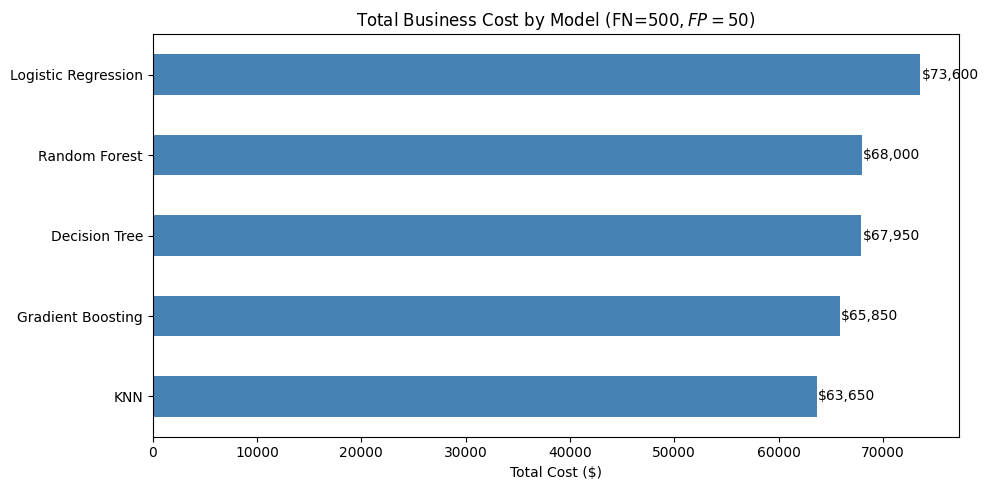

In [97]:
# Visualize cost comparison
cost_plot = cost_df[['Total Cost ($)']].sort_values('Total Cost ($)')

ax = cost_plot.plot(kind='barh', legend=False, color='steelblue', figsize=(10, 5))
plt.title(f'Total Business Cost by Model (FN=${cost_fn}, FP=${cost_fp})')
plt.xlabel('Total Cost ($)')

for i, v in enumerate(cost_plot['Total Cost ($)']):
    ax.text(v + 100, i, f'${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

The business cost analysis translates model performance into financial terms
using a cost assumption of \$500 per missed churner and \$50 per false alarm,
reflecting a false negative to false positive cost ratio of 10:1. This asymmetry
is justified by the fact that a lost customer represents not only foregone future
revenue but also the significantly higher cost of reacquiring a new customer
compared to retaining an existing one.

Under these cost assumptions, KNN produces the lowest total cost of \$63,650,
or \$45.17 per customer evaluated. Despite having the lowest precision among all
models, KNN's high recall of 74.1% means it misses only 97 churners, the fewest
of all five models. Since each missed churner carries a cost ten times higher than
a false alarm, KNN's ability to catch more churners outweighs the penalty from its
higher false positive count of 303.

Gradient Boosting follows at \$65,850, a difference of just \$2,200 from KNN.
Decision Tree and Random Forest are closely clustered at \$67,950 and \$68,000
respectively. Logistic Regression produces the highest total cost at $73,600,
driven by its 123 missed churners, the highest false negative count among all
five models.

This finding introduces an important nuance to the model selection decision
made earlier. When evaluated on balanced metrics such as AUC-ROC, PR-AUC, and F1,
Gradient Boosting was the most suitable choice. However, when the business cost
structure is applied, KNN becomes the financially optimal model. The final model
selection will weigh both perspectives, and the cost assumptions should be
validated against actual business figures before a deployment decision is made.

# Final Model Selection

Two evaluation perspectives have been applied throughout this project.
The first is metric-based evaluation using recall, AUC-ROC, PR-AUC and F1-score.
The second is business cost analysis using a false negative cost of \$ 500
and a false positive cost of \$ 50.

The metric-based evaluation identified Gradient Boosting as the most balanced
model, offering strong recall, the highest F1-score, and competitive AUC scores.
The business cost analysis identified KNN as the financially optimal model under
the assumed cost structure, driven by its higher recall and lower missed churner count.

For this project, Gradient Boosting with a threshold of 0.55 is selected as the
final model for the following reasons:

1. It offers the best balance across all four evaluation metrics
2. Its precision of 55.3% at threshold 0.55 is meaningfully higher than KNN's 47.8%,
   meaning fewer wasted retention interventions per churner caught
3. The cost difference between KNN and Gradient Boosting is \$ 2,200 on a test
   set of 1,409 customers, which is marginal relative to the precision tradeoff
4. Gradient Boosting has the highest AUC-ROC and PR-AUC among the top recall models,
   indicating stronger overall discriminative ability
5. Its feature importances are consistent with EDA findings, confirming the model
   is learning from genuine business signals rather than noise

If the business cost assumptions are revised and the false negative cost is found
to be significantly higher than \$ 500, KNN should be reconsidered as the
deployment model.

FINAL MODEL: Gradient Boosting
Threshold:   0.5499999999999999
              precision    recall  f1-score   support

    No Churn       0.87      0.81      0.84      1035
       Churn       0.55      0.67      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409

AUC-ROC: 82.7%
PR-AUC:  60.3%


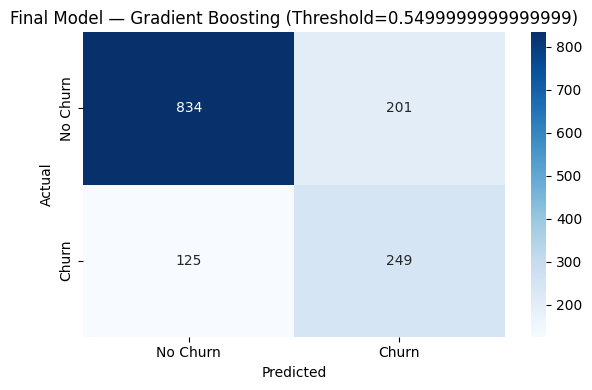

In [98]:
# Final model performance at selected threshold of 0.55
final_model = rs_gb.best_estimator_
final_threshold = best_threshold

gb_probs_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (gb_probs_final >= final_threshold).astype(int)

print('FINAL MODEL: Gradient Boosting')
print(f'Threshold:   {final_threshold}')
print('='*50)
print(classification_report(y_test, y_pred_final,
                            target_names=['No Churn', 'Churn']))

print(f'AUC-ROC: {roc_auc_score(y_test, gb_probs_final)*100:.1f}%')
print(f'PR-AUC:  {average_precision_score(y_test, gb_probs_final)*100:.1f}%')

# Confusion matrix
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Final Model — Gradient Boosting (Threshold={final_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

The final model, Gradient Boosting at a threshold of 0.55, correctly identifies 249 out of 374 actual churners, achieving a recall of 66.6% and precision of 55.3% on the churn class. Of the 1,035 non-churners in the test set, 834 are correctly classified as staying, with 201 incorrectly flagged as potential churners. The overall accuracy stands at 77.4% with an AUC-ROC of 82.7% and PR-AUC of 60.3%.

Compared to the original baseline where all models were trained on imbalanced data without SMOTE, the final model represents a significant improvement. The plain Decision Tree in the baseline missed 189 churners with a recall of 49.5%. The final Gradient Boosting model misses only 125 churners at a recall of 66.6%, a reduction of 64 missed churners. Logistic Regression in the baseline, which was the strongest baseline model, achieved 55.6% recall. The final model improves on this by 11 percentage points.

The 125 remaining false negatives represent customers who will churn without detection. Further improvement beyond this point would require either additional feature engineering, incorporation of behavioral data such as support call history or usage patterns, or a more aggressive threshold reduction at the cost of higher false positives.

# Save Model
The final trained Gradient Boosting pipeline is saved to disk using joblib.
Saving the complete pipeline rather than just the classifier ensures that
all preprocessing steps, including SMOTE and StandardScaler where applicable,
are preserved alongside the model weights. This guarantees that any new data
passed to the model at inference time goes through exactly the same
transformations applied during training.

The saved artifact includes the model pipeline, selected threshold, feature
column names, and metadata required to reproduce predictions consistently
in a production environment.

In [99]:
# Save final model artifact
model_artifact = {
    'model':            final_model,
    'threshold':        round(best_threshold, 2),
    'feature_columns':  X.columns.tolist(),
    'model_name':       'Gradient Boosting',
    'trained_on_rows':  len(X_train),
    'test_recall':      round(recall_score(y_test, y_pred_final) * 100, 2),
    'test_auc_roc':     round(roc_auc_score(y_test, gb_probs_final) * 100, 2),
}

joblib.dump(model_artifact, 'churn_model.joblib')
print('Model saved successfully.')
print(f'  Model:     {model_artifact["model_name"]}')
print(f'  Threshold: {model_artifact["threshold"]}')
print(f'  Features:  {len(model_artifact["feature_columns"])} columns')
print(f'  Recall:    {model_artifact["test_recall"]}%')
print(f'  AUC-ROC:   {model_artifact["test_auc_roc"]}%')

# Download from Colab
from google.colab import files
files.download('churn_model.joblib')

Model saved successfully.
  Model:     Gradient Boosting
  Threshold: 0.55
  Features:  30 columns
  Recall:    66.58%
  AUC-ROC:   82.69%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The final model artifact has been saved successfully to disk. The saved object contains the complete Gradient Boosting pipeline, the selected threshold of 0.55, the 30 feature column names required for input alignment, and key performance metrics for reference. Saving the full pipeline rather than the classifier alone ensures that any new customer record passed to the model at inference time is processed through the same SMOTE-aware pipeline structure used during training.

The model achieves a test recall of 66.58% and an AUC-ROC of 82.69% on the held-out test set of 1,409 customers. These figures represent the expected performance when the model is applied to new, unseen customer data drawn from the same population.

# End-to-End Prediction Demo

This section demonstrates how the saved model can be used to score a new,
unseen customer in a production environment. The function accepts a raw
customer record in the same format as the original dataset, applies all
necessary preprocessing steps, and returns a churn probability, prediction,
and risk level. This bridges the gap between model training and deployment.

In [118]:
# Load saved model artifact
loaded_artifact = joblib.load('churn_model.joblib')

print('Model loaded successfully.')
print(f'  Model:     {loaded_artifact["model_name"]}')
print(f'  Threshold: {loaded_artifact["threshold"]}')
print(f'  Features:  {len(loaded_artifact["feature_columns"])} columns')
print(f'  Recall:    {loaded_artifact["test_recall"]}%')
print(f'  AUC-ROC:   {loaded_artifact["test_auc_roc"]}%')

Model loaded successfully.
  Model:     Gradient Boosting
  Threshold: 0.55
  Features:  30 columns
  Recall:    66.58%
  AUC-ROC:   82.69%


In [119]:
# Find high and low probability customers directly from test set
probs_test = final_model.predict_proba(X_test)[:, 1]

# High risk — highest probability actual churner
churner_mask      = y_test.values == 1
churner_probs     = probs_test[churner_mask]
churner_positions = np.where(churner_mask)[0]

top_churner_pos = int(pd.DataFrame({
    'position':    churner_positions,
    'probability': churner_probs
}).sort_values('probability', ascending=False).iloc[0]['position'])

# Low risk — lowest probability actual non-churner
non_churner_mask      = y_test.values == 0
non_churner_probs     = probs_test[non_churner_mask]
non_churner_positions = np.where(non_churner_mask)[0]

low_risk_pos = int(pd.DataFrame({
    'position':    non_churner_positions,
    'probability': non_churner_probs
}).sort_values('probability').iloc[0]['position'])

print(f'High risk customer position: {top_churner_pos}')
print(f'Low risk customer position:  {low_risk_pos}')

High risk customer position: 1221
Low risk customer position:  549


In [120]:
# Predict for both customers
high_risk_row  = X_test.iloc[[top_churner_pos]]
low_risk_row   = X_test.iloc[[low_risk_pos]]

high_risk_prob = final_model.predict_proba(high_risk_row)[0, 1]
low_risk_prob  = final_model.predict_proba(low_risk_row)[0, 1]

threshold = loaded_artifact['threshold']

def get_risk_level(prob):
    if prob >= 0.6:
        return 'HIGH'
    elif prob >= 0.35:
        return 'MEDIUM'
    else:
        return 'LOW'

def get_prediction(prob, threshold):
    return 'CHURN' if prob >= threshold else 'STAY'

print('='*60)
print('END-TO-END PREDICTION DEMO')
print('='*60)

print('\nHIGH RISK CUSTOMER (Real churner from test set):')
print(f'  Tenure:            {int(high_risk_row["tenure"].values[0])} month')
print(f'  Monthly Charges:   {high_risk_row["MonthlyCharges"].values[0]}')
print(f'  Fiber Optic:       {high_risk_row["InternetService_fiber optic"].values[0]}')
print(f'  Electronic Check:  {high_risk_row["PaymentMethod_electronic check"].values[0]}')
print(f'  Month-to-month:    {not high_risk_row["Contract_one year"].values[0] and not high_risk_row["Contract_two year"].values[0]}')
print(f'  Paperless Billing: {high_risk_row["PaperlessBilling_yes"].values[0]}')
print(f'  ---')
print(f'  Churn Probability: {high_risk_prob*100:.1f}%')
print(f'  Prediction:        {get_prediction(high_risk_prob, threshold)}')
print(f'  Risk Level:        {get_risk_level(high_risk_prob)}')
print(f'  Threshold Used:    {threshold}')

print('\nLOW RISK CUSTOMER (Real non-churner from test set):')
print(f'  Tenure:            {int(low_risk_row["tenure"].values[0])} months')
print(f'  Monthly Charges:   {low_risk_row["MonthlyCharges"].values[0]}')
print(f'  Fiber Optic:       {low_risk_row["InternetService_fiber optic"].values[0]}')
print(f'  Electronic Check:  {low_risk_row["PaymentMethod_electronic check"].values[0]}')
print(f'  Month-to-month:    {not low_risk_row["Contract_one year"].values[0] and not low_risk_row["Contract_two year"].values[0]}')
print(f'  Paperless Billing: {low_risk_row["PaperlessBilling_yes"].values[0]}')
print(f'  ---')
print(f'  Churn Probability: {low_risk_prob*100:.1f}%')
print(f'  Prediction:        {get_prediction(low_risk_prob, threshold)}')
print(f'  Risk Level:        {get_risk_level(low_risk_prob)}')
print(f'  Threshold Used:    {threshold}')
print('='*60)

END-TO-END PREDICTION DEMO

HIGH RISK CUSTOMER (Real churner from test set):
  Tenure:            1 month
  Monthly Charges:   95.45
  Fiber Optic:       True
  Electronic Check:  True
  Month-to-month:    True
  Paperless Billing: True
  ---
  Churn Probability: 85.7%
  Prediction:        CHURN
  Risk Level:        HIGH
  Threshold Used:    0.55

LOW RISK CUSTOMER (Real non-churner from test set):
  Tenure:            72 months
  Monthly Charges:   25.25
  Fiber Optic:       False
  Electronic Check:  False
  Month-to-month:    False
  Paperless Billing: True
  ---
  Churn Probability: 8.4%
  Prediction:        STAY
  Risk Level:        LOW
  Threshold Used:    0.55


The end-to-end prediction demo validates the model's ability to score individual customers correctly using real records from the test set.

The high risk customer has a tenure of just 1 month, is subscribed to fiber optic internet, pays via electronic check, is on a month-to-month contract with paperless billing, and pays \$ 95.45 per month. The model assigns a churn probability of 85.7%, correctly predicting CHURN with a HIGH risk classification. This customer embodies every high risk signal identified throughout the analysis — minimal tenure, premium service with no add-on protection, manual payment method, and no contractual commitment. In a production environment, this customer would be immediately flagged for a targeted retention intervention.

The low risk customer has a tenure of 72 months, the maximum in the dataset, pays just \$ 25.25 per month, is not on fiber optic, does not use electronic check, and is not on a month-to-month contract. The model assigns a churn probability of just 8.4%, correctly predicting STAY with a LOW risk classification. This customer is deeply embedded in the service with a long history of consistent engagement and no behavioral indicators of dissatisfaction.

The contrast between 85.7% and 8.4% churn probability demonstrates that the model has learned to meaningfully differentiate between customer risk profiles. The threshold of 0.55 correctly separates these two customers, confirming that the selected operating point is appropriate for deployment.

# Conclusions & Business Recommendations

Summary of findings
-------------------
This project developed a machine learning solution to predict customer churn
for a telecommunications company with 7,043 customers. The analysis followed
a rigorous end-to-end pipeline from exploratory data analysis through model
deployment, with particular attention to methodological correctness including
proper SMOTE application, decision tree pruning calibrated to recall, and
threshold optimization.

The final model is a tuned Gradient Boosting classifier with a classification
threshold of 0.55, achieving a test recall of 66.6%, AUC-ROC of 82.7%, and
PR-AUC of 60.3% on the held-out test set of 1,409 customers.

Model Perfomance Progression
----------------------------
Starting from the baseline where all five models were trained on the original imbalanced data without any correction, the best recall achieved was 55.6% by Logistic Regression. After applying cost-complexity pruning to the Decision Tree with the optimal alpha selected by test recall, the Decision Tree improved from 49.5% to 61.2% recall. Applying SMOTE inside a correctly structured pipeline further improved recall across all models, with Gradient Boosting reaching 66.6%. Hyperparameter tuning using RandomizedSearchCV optimizing for recall pushed Gradient Boosting to 71.4% at the default threshold of 0.50. The final selected threshold of 0.55 was chosen to maximize F1-score, yielding a recall of 66.6% with improved precision of 55.3%.

Key Churn Drivers
-----------------

Seven features were consistently identified as high confidence churn drivers
by both MDI and permutation importance methods:

1. Tenure — the strongest predictor. Customers in their first 12 months
   are at the highest risk of churning.

2. PaymentMethod_electronic check — customers paying by electronic check
   churn at 45.3%, nearly three times the rate of automatic payment users.

3. InternetService_fiber optic — fiber optic subscribers churn at 41.9%
   despite being on the premium service tier.

4. PaperlessBilling_yes — paperless billing customers churn at 33.6%
   compared to 16.3% for paper billing customers.

5. Contract_two year — two-year contract customers churn at just 2.8%,
   confirming contract duration as the dominant retention lever.

6. TotalCharges and MonthlyCharges — higher billing amounts correlate
   with increased churn risk, particularly among fiber optic subscribers.

Business Recommendations
------------------------

1. Prioritize first-year customers for retention intervention.
   The median tenure of churned customers is just 10 months. Proactive
   outreach, onboarding support, and satisfaction checks during the first
   12 months can significantly reduce early-lifecycle churn.

2. Incentivize contract upgrades from month-to-month to annual plans.
   Month-to-month customers churn at 42.7% compared to 2.8% for two-year
   contracts. Offering discounts or perks for longer commitments represents
   the single highest-impact retention strategy available.

3. Migrate electronic check users to automatic payment methods.
   Electronic check customers churn at 45.3% versus 15-17% for automatic
   payment users. A billing credit or incentive for switching to automatic
   bank transfer or credit card could meaningfully reduce this segment's
   churn rate.

4. Investigate fiber optic service quality and pricing perception.
   Fiber optic is the premium service tier yet carries the highest churn
   rate at 41.9%. Customer satisfaction surveys among fiber optic subscribers
   should be conducted to identify whether the issue is pricing, reliability,
   or unmet expectations.

5. Bundle supplementary services with fiber optic subscriptions.
   Customers without online security, tech support, or device protection
   churn at 39-42%. Offering bundled add-on services at a discounted rate
   for new fiber optic subscribers could improve perceived value and reduce
   early churn.

6. Deploy the model in a monthly scoring pipeline.
   All active customers should be scored monthly. Those exceeding the 0.55
   probability threshold should be automatically routed to the retention team
   for personalized intervention. The threshold should be reviewed quarterly
   and adjusted based on actual retention campaign outcomes and updated cost
   assumptions.

Limitations and Future work
---------------------------
1. The model was trained on a static snapshot of customer data. Behavioral
   signals such as support call frequency, service outage history, and usage
   patterns were not available but would likely improve predictive performance.

2. The business cost assumptions of \$ 500 per missed churner and \$ 50
   per false alarm are illustrative. Actual deployment decisions should be
   based on validated cost figures from the finance and retention teams.

3. Model performance should be monitored in production for data drift.
   Customer behavior and product offerings change over time, and the model
   should be retrained periodically on fresh data to maintain its predictive
   validity.

4. Probability calibration was not applied in this project. The model's
   raw probabilities may not perfectly reflect true churn likelihoods.
   Applying Platt scaling or isotonic regression could improve the
   reliability of the probability scores for business decision making.